
# ECG Arrhythmia Classification with GAN Balancing — End‑to‑End Notebook

**What you get (turn‑key):**
- Preprocessing: Butterworth filter → R‑peak detection → beat segmentation (1D waves)
- Dataset representation & plots + label counts (before/after balancing)
- Conditional **WGAN‑GP** to generate *synthetic ECG beats* for minority classes (N,S,V,F, optional Q)
- Train/test splits comparison: **60:40**, **70:30**, **80:20**
- Epoch budget comparison (configurable): e.g., **10 / 20 / 30**
- Two classifiers: CNN and LSTM(depthwise‑separable)
- Full metrics: train acc, test acc, precision, recall, macro‑F1, confusion matrix
- Saves **all trained models** and experiment artifacts
- Picks the **best model** and shows **inference** on new beats

> **Reference inspiration:** ACGAN‑based augmentation and CNN and LSTM comparison ideas are adapted from Bechinia *et al.*, 2024 (IEEE Access). Please cite the paper if you use this notebook in your work.



## 0. Quick start & configuration

- If you already have preprocessed arrays, place them here:
  - `artifacts/X.npy` (shape: `[n_beats, 1, L]`) and `artifacts/y.npy` (list/array of labels like `['N','V',...]`)
- Or point `PHYSIO_DIR` to your **MIT‑BIH** WFDB records to build arrays automatically.
- Set `DEMO_MODE=True` to simulate a tiny dataset (for quick pipeline checks); set to `False` for real runs.
- Trained models & reports are saved under `artifacts/`.


In [1]:

# --- Global config ---
import os, sys, json, math, time, random, pathlib
from pathlib import Path

DEMO_MODE   = False    # <- set True to simulate data for quick checks
SEED        = 1337
ART_DIR     = Path("artifacts"); ART_DIR.mkdir(exist_ok=True, parents=True)

# If you have WFDB MIT‑BIH locally, set this to that folder (contains .dat/.hea/.atr etc.)
PHYSIO_DIR  = Path("physionet_mitbih")

# Beat window length (samples). Common: 187 (MIT‑BIH downstream), Paper example used 256.
BEAT_LEN    = 187

# Class set. Use 4 or 5 classes depending on your labels.
CLASS_ORDER = ['N','S','V','F']  # add 'Q' later if present in data (auto‑detected)

# Split ratios to compare (train:test). A small slice of train is used as validation.
SPLITS      = [(0.6, 0.4), (0.7, 0.3), (0.8, 0.2)]

# Epoch budgets to compare
EPOCH_CHOICES = [10, 20, 30]

# Training
BATCH_SIZE      = 256
VAL_FRAC        = 0.1     # fraction of TRAIN reserved for validation
NUM_WORKERS     = 0       # increase if using DataLoader with multiple workers

# Augmentation target: balance to max class count (majority) or a fixed cap
BALANCE_TO_MAJORITY = True
BALANCE_CAP         = None   # e.g., 20000 (if not using majority)

# Device
import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# Reproducibility
import numpy as np
import pandas as pd
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

# Utility: timestamped tag
def tagify(dsplit, epochs, balanced, model_name):
    bflag = 'bal' if balanced else 'raw'
    return f"{model_name}@{int(dsplit*100)}/{epochs}e_{bflag}_{int(time.time())}"


Using device: cuda


In [2]:

import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, find_peaks

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split

# NOTE: Per instructions for plotting:
# - Use matplotlib (not seaborn)
# - Single chart per figure
# - Do not set specific colors/styles

def plot_counts(counts, title):
    plt.figure()
    labels = list(counts.keys())
    values = [counts[k] for k in labels]
    plt.bar(labels, values)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

def plot_wave(wave, title="ECG beat"):
    plt.figure()
    plt.plot(wave.squeeze())
    plt.title(title)
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")
    plt.show()

from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
import joblib


In [3]:
# # === SHOW FIRST 5 ECG SAMPLES WITH 188 FEATURES AND LABEL ===
# import numpy as np
# import pandas as pd
# from IPython.display import display, Markdown

# # Ensure dataset is loaded and correctly shaped
# X_all = np.array(X_all)
# if X_all.ndim == 3:
#     X_all = X_all.reshape(X_all.shape[0], -1)
# elif X_all.ndim == 1:
#     X_all = np.stack(X_all, axis=0)

# n_samples, n_points = X_all.shape

# if n_points != 188:
#     print(f"⚠️ Warning: Each sample has {n_points} points (expected 188). Still showing first 5 records.")

# # --- Build a DataFrame for display ---
# n_show = 5
# df_preview = pd.DataFrame(X_all[:n_show], columns=[f"F{i+1}" for i in range(X_all.shape[1])])
# df_preview["Label"] = y_all[:n_show]

# # --- Display neatly ---
# display(Markdown(f"### 📊 First {n_show} ECG Samples (Each with {X_all.shape[1]} Features)"))
# display(df_preview)

# # --- Optional: Save this small preview to CSV for reports ---
# from pathlib import Path
# ART_DIR = Path("artifacts")
# ART_DIR.mkdir(exist_ok=True, parents=True)
# df_preview.to_csv(ART_DIR / "first_5_samples_preview.csv", index=False)
# print(f"✅ Saved table: {ART_DIR / 'first_5_samples_preview.csv'}")


In [4]:
# # === INITIAL CELL: DATASET OVERVIEW & STRUCTURE (Shape-Agnostic) ===
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from collections import Counter
# from IPython.display import Markdown, display

# # --- 1️⃣ Load dataset arrays ---
# try:
#     X_all, y_all  # already loaded in memory
# except NameError:
#     from pathlib import Path
#     ART_DIR = Path("artifacts")
#     if (ART_DIR / "X_all.npy").exists() and (ART_DIR / "y_all.npy").exists():
#         X_all = np.load(ART_DIR / "X_all.npy", allow_pickle=True)
#         y_all = np.load(ART_DIR / "y_all.npy", allow_pickle=True)
#     else:
#         raise RuntimeError("X_all and y_all not found. Please load the MIT-BIH dataset first.")

# # --- 2️⃣ Handle shape automatically ---
# X_all = np.array(X_all)
# if X_all.ndim == 3:
#     # Flatten 3D arrays (e.g. (n,1,188) or (n,188,1)) to 2D
#     X_all = X_all.reshape(X_all.shape[0], -1)
# elif X_all.ndim == 1:
#     # Convert list of arrays to 2D
#     X_all = np.stack(X_all, axis=0)

# n_samples, n_points = X_all.shape
# unique_classes = sorted(list(set(y_all)))
# cnt = dict(Counter(y_all.tolist()))

# summary_md = f"""
# ### 🩺 **MIT-BIH ECG Dataset Overview**

# - **Total beats (records):** {n_samples:,}  
# - **Samples per beat (vector length):** {n_points}  
# - **Number of classes:** {len(unique_classes)}  
# - **Classes present:** {', '.join(unique_classes)}  

# Each heartbeat is represented as a **1D vector of {n_points} points**, corresponding to one ECG waveform segment.
# """
# display(Markdown(summary_md))

# # --- 3️⃣ Class distribution ---
# df_counts = pd.DataFrame({
#     "Class": unique_classes,
#     "Count": [cnt[c] for c in unique_classes]
# })
# df_counts["%"] = (df_counts["Count"] / df_counts["Count"].sum() * 100).round(2)
# display(df_counts)

# plt.figure(figsize=(6,4))
# plt.bar(df_counts["Class"], df_counts["Count"], color="teal", alpha=0.8)
# plt.title("Class Distribution — Number of ECG Beats per Class")
# plt.xlabel("Class Label")
# plt.ylabel("Count")
# plt.grid(axis="y", linestyle="--", alpha=0.6)
# plt.tight_layout()
# plt.show()

# # --- 4️⃣ Show sample ECG waveforms (188-point vectors) ---
# n_show = 5
# sel_idx = np.random.choice(len(X_all), n_show, replace=False)
# plt.figure(figsize=(10,6))
# for i, idx in enumerate(sel_idx):
#     plt.plot(X_all[idx], label=f"Sample {i+1} — Class {y_all[idx]}")
# plt.title(f"Example ECG Beat Waveforms (each with {n_points} points)")
# plt.xlabel("Sample index (time)")
# plt.ylabel("Amplitude (normalized)")
# plt.legend()
# plt.grid(True, linestyle="--", alpha=0.5)
# plt.tight_layout()
# plt.show()

# # --- 5️⃣ Summary note ---
# display(Markdown(f"""
# ✅ The dataset consists of **{n_samples:,} ECG beat segments** from the MIT-BIH Arrhythmia Database.  
# Each beat is a **{n_points}-sample 1D vector** capturing the ECG waveform around the R-peak.  
# These vectors are used as inputs to models (CNN, LSTM, etc.) for classifying heartbeat types:
# - **N** – Normal beat  
# - **S** – Supraventricular ectopic beat  
# - **V** – Ventricular ectopic beat  
# - **F** – Fusion beat  
# - **Q** – Unknown/Noise beat  
# """))



## 1. Preprocessing functions

Includes:
- Butterworth band‑pass filter (0.5–50 Hz default)
- R‑peak detection
- Beat segmentation and trimming/padding to `BEAT_LEN`


In [5]:

from typing import Tuple, List, Dict

def butter_bandpass(lowcut=0.5, highcut=50.0, fs=360.0, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def bandpass_filter(x, fs=360.0, lowcut=0.5, highcut=50.0, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    return filtfilt(b, a, x)

def segment_beats(signal, r_peaks, left=64, right=123):
    # returns array of shape [n_beats, 1, BEAT_LEN]
    beats = []
    for rp in r_peaks:
        start = max(0, rp - left)
        end   = min(len(signal), rp + right + 1)
        beat = signal[start:end]
        # pad or crop to BEAT_LEN
        if len(beat) < BEAT_LEN:
            pad_left = (BEAT_LEN - len(beat)) // 2
            pad_right = BEAT_LEN - len(beat) - pad_left
            beat = np.pad(beat, (pad_left, pad_right), mode='edge')
        elif len(beat) > BEAT_LEN:
            extra = len(beat) - BEAT_LEN
            start_crop = extra // 2
            beat = beat[start_crop:start_crop+BEAT_LEN]
        beats.append(beat.astype('float32')[None, :])  # [1, L]
    if len(beats) == 0:
        return np.zeros((0,1,BEAT_LEN), dtype='float32')
    return np.stack(beats, axis=0)

# Example R‑peak detection wrapper (thresholds are simplistic; tune for your data)
def detect_r_peaks(filtered_signal, distance=100, height=None):
    peaks, _ = find_peaks(filtered_signal, distance=distance, height=height)
    return peaks



## 2. Load data (arrays or WFDB) — with a DEMO fallback

- If `artifacts/X.npy` & `artifacts/y.npy` exist, they will be loaded.
- Otherwise, **DEMO mode** can synthesize a small, imbalanced dataset for pipeline testing.
- (Optional) Extend to parse WFDB records under `PHYSIO_DIR` if needed.



### 1.1 WFDB end-to-end loader (MIT-BIH → beats)

If `artifacts/X.npy` and `artifacts/y.npy` are **not** present, this section will:
- Parse all listed **MIT-BIH** records from `PHYSIO_DIR`
- Use **annotation symbols** to extract beat labels
- Map symbols to **AAMI classes**: **N, S, V, F, Q**
- Segment fixed-length beats around annotation sample positions
- Save `artifacts/X.npy` and `artifacts/y.npy` for subsequent runs

> Requires the `wfdb` package. The cell will attempt to install it if missing.


In [6]:

# --- WFDB loader for MIT-BIH ---
# This cell runs ONLY when X.npy/y.npy are missing.
# It builds full-dataset arrays and saves them to artifacts/ for future runs.

import sys, subprocess, importlib

def _ensure_pkg(pkg):
    try:
        importlib.import_module(pkg)
    except ImportError:
        print(f"Installing {pkg} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
    return importlib.import_module(pkg)

wfdb = _ensure_pkg("wfdb")

# Full MIT-BIH record list (same as commonly used in literature)
RECORDS_ALL = [
    '100','101','102','103','104','105','106','107','108','109',
    '111','112','113','114','115','116','117','118','119',
    '121','122','123','124','200','201','202','203','205','207',
    '208','209','210','212','213','214','215','217','219','220',
    '221','222','223','228','230','231','232','233','234'
]

# AAMI mapping (ANSI/AAMI EC57): symbol -> class
AAMI_MAP = {
    # N (Normal)
    'N':'N','L':'N','R':'N','e':'N','j':'N',
    # S (Supraventricular ectopic)
    'A':'S','a':'S','J':'S','S':'S',
    # V (Ventricular ectopic)
    'V':'V','E':'V',
    # F (Fusion of ventricular and normal)
    'F':'F',
    # Q (Unknown / paced / others)
    '/':'Q','f':'Q','Q':'Q','|':'Q','~':'Q','p':'Q','P':'Q'
}

def _map_symbol_to_aami(sym):
    return AAMI_MAP.get(sym, None)

def _segment_fixed(sig, center, left=64, right=123):
    start = max(0, center - left)
    end   = min(len(sig), center + right + 1)
    beat  = sig[start:end]
    if len(beat) < BEAT_LEN:
        pad_left  = (BEAT_LEN - len(beat)) // 2
        pad_right = BEAT_LEN - len(beat) - pad_left
        beat = np.pad(beat, (pad_left, pad_right), mode='edge')
    elif len(beat) > BEAT_LEN:
        extra = len(beat) - BEAT_LEN
        s0 = extra // 2
        beat = beat[s0:s0+BEAT_LEN]
    return beat.astype('float32')

def build_arrays_from_wfdb(physio_dir, use_channel=0, fs_assumed=360.0):
    Xs, Ys = [], []
    for rec in RECORDS_ALL:
        rec_path = str(physio_dir / rec)
        try:
            rd = wfdb.rdrecord(rec_path)
            ann = wfdb.rdann(rec_path, 'atr')
        except Exception as e:
            print(f"[WARN] Skipping record {rec} due to: {e}")
            continue
        # pick channel
        sig = rd.p_signal[:, use_channel].astype('float32')
        # optional: filter
        sig_f = bandpass_filter(sig, fs=fs_assumed, lowcut=0.5, highcut=50.0, order=4)
        # annotations
        samp = ann.sample
        syms = ann.symbol
        for s, sym in zip(samp, syms):
            cls = _map_symbol_to_aami(sym)
            if cls is None:
                continue  # skip unmapped
            beat = _segment_fixed(sig_f, int(s), left=64, right=123)
            Xs.append(beat[None,:])  # [1, L]
            Ys.append(cls)
    X = np.stack(Xs, axis=0)
    y = np.array(Ys)
    return X, y

# Only run if arrays not present
xp, yp = ART_DIR / "X.npy", ART_DIR / "y.npy"
if not (xp.exists() and yp.exists()):
    if not PHYSIO_DIR.exists():
            print(f"PHYSIO_DIR={PHYSIO_DIR} not found. Attempting to download MIT-BIH (mitdb) from PhysioNet...")
            PHYSIO_DIR.mkdir(parents=True, exist_ok=True)
    try:
        wfdb.dl_database('mitdb', dl_dir=str(PHYSIO_DIR), keep_subdirs=False)
        print("Download complete. Proceeding to build arrays...")
    except Exception as e:
        raise FileNotFoundError(
            f"Could not download MIT-BIH automatically: {e}. "
            f"Please download manually and set PHYSIO_DIR."
        )


    print("Building full dataset from WFDB records... this may take several minutes.")
    X_full, y_full = build_arrays_from_wfdb(PHYSIO_DIR, use_channel=0, fs_assumed=360.0)
    # Keep only classes present in CLASS_ORDER + auto-extend for Q if present
    uniq = sorted(set(y_full.tolist()))
    for c in uniq:
        if c not in CLASS_ORDER:
            CLASS_ORDER.append(c)
    np.save(xp, X_full.astype('float32'))
    np.save(yp, y_full)
    print("Saved arrays:", xp, yp, X_full.shape, len(y_full))
else:
    print("Found existing arrays; WFDB build skipped.")


Found existing arrays; WFDB build skipped.


In [7]:

def try_load_arrays():
    xp = ART_DIR / "X.npy"
    yp = ART_DIR / "y.npy"
    if xp.exists() and yp.exists():
        X = np.load(xp, allow_pickle=True)
        y = np.load(yp, allow_pickle=True)
        return X, y
    return None, None

# def simulate_dataset(n_total=8000, class_weights={'N':0.75,'S':0.06,'V':0.15,'F':0.04}):
#     # Create synthetic sine‑like beats per class (imbalanced) for quick testing
#     Xs, Ys = [], []
#     for lbl, w in class_weights.items():
#         n = int(n_total * w)
#         for _ in range(n):
#             t = np.linspace(0, 1, BEAT_LEN, endpoint=False)
#             base = np.sin(2*np.pi*(5+np.random.rand()*10)*t)
#             noise = 0.05*np.random.randn(BEAT_LEN)
#             # class‑specific tweak
#             if lbl=='S': base += 0.2*np.sin(2*np.pi*50*t)
#             if lbl=='V': base = np.sign(base) * np.abs(base)**0.5
#             if lbl=='F': base = 0.5*base + 0.5*np.sin(2*np.pi*2*t)
#             beat = (base + noise).astype('float32')
#             Xs.append(beat[None,:])
#             Ys.append(lbl)
#     X = np.stack(Xs, axis=0).astype('float32')
#     y = np.array(Ys)
#     return X, y

# TODO: Extend: build from WFDB (not included here to keep notebook focused and light).
# You can adapt by reading signals, filtering, find R‑peaks, segment_beats(...), map annotations -> labels.

X_all, y_all = try_load_arrays()
if X_all is None or y_all is None:
    if DEMO_MODE:
        print("No arrays found. DEMO_MODE=True -> creating synthetic imbalanced dataset.")
        X_all, y_all = simulate_dataset()
    else:
        raise FileNotFoundError("Couldn't find arrays. Please place X.npy/y.npy in artifacts/ or enable DEMO_MODE.")

print("Loaded:", X_all.shape, len(y_all))
print("Unique labels:", np.unique(y_all, return_counts=True))


Loaded: (110242, 1, 187) 110242
Unique labels: (array(['F', 'N', 'Q', 'S', 'V'], dtype='<U1'), array([  803, 90631,  8791,  2781,  7236]))



## 3. Dataset representation & sample plots


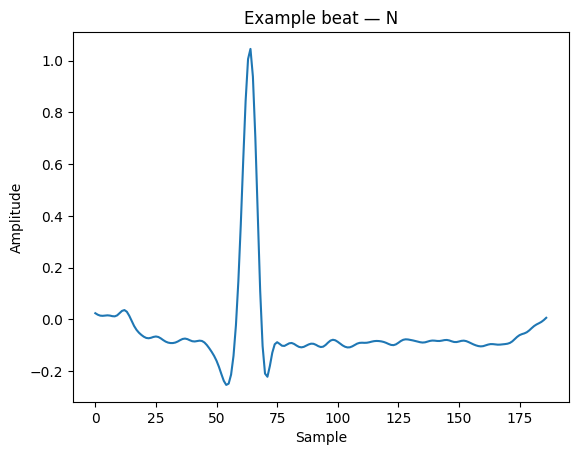

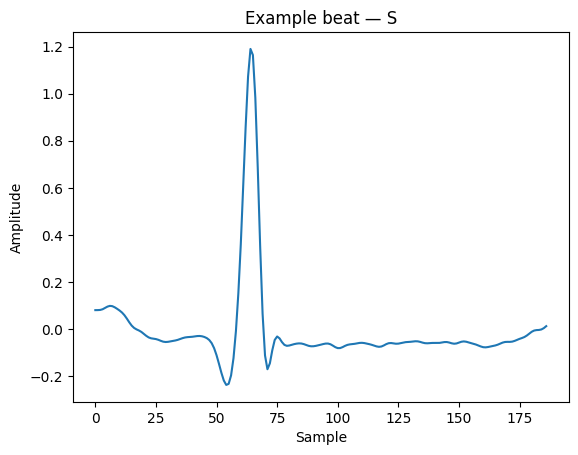

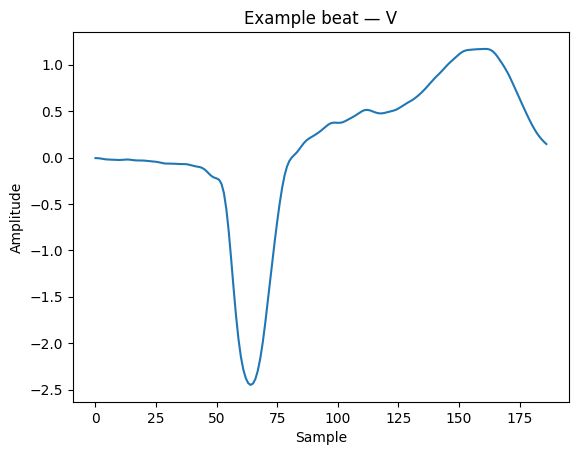

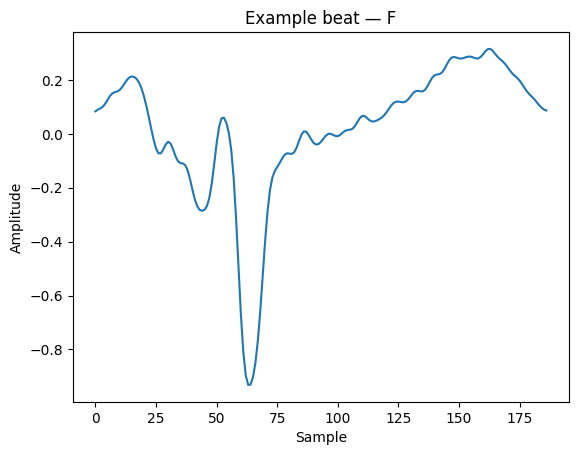

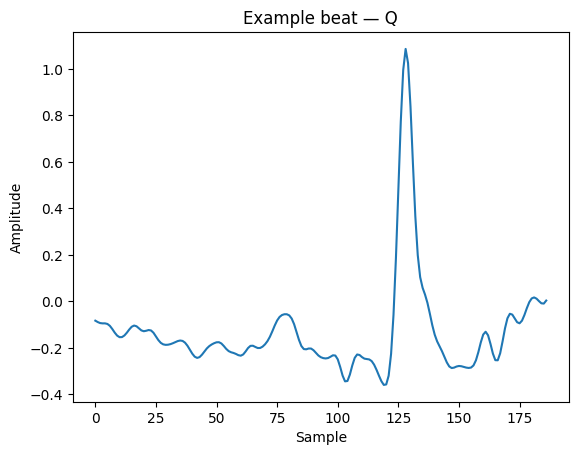

Counts before balancing: {'N': 90631, 'S': 2781, 'V': 7236, 'Q': 8791, 'F': 803}


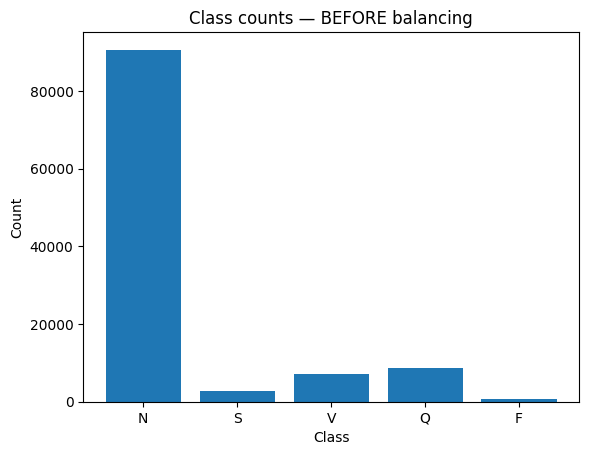

In [8]:

# Ensure CLASS_ORDER contains only classes present
present = list(sorted(np.unique(y_all).tolist()))
for c in present:
    if c not in CLASS_ORDER:
        CLASS_ORDER.append(c)

# Show one example per class
for c in CLASS_ORDER:
    idxs = np.where(y_all==c)[0]
    if len(idxs)==0: 
        continue
    plot_wave(X_all[idxs[0]], title=f"Example beat — {c}")

# Counts
from collections import Counter
counts_before = dict(Counter(y_all.tolist()))
print("Counts before balancing:", counts_before)
plot_counts(counts_before, "Class counts — BEFORE balancing")



## 4. Conditional WGAN‑GP (1D) for class‑aware beat synthesis

This GAN learns to generate 1D beats `x ∈ R^{BEAT_LEN}` conditioned on class labels.  
We use gradient penalty for stability; the generator uses label embeddings.


In [9]:

import torch.nn as nn
import torch.nn.functional as F

N_CLASSES = len(CLASS_ORDER)
CLASS2IDX = {c:i for i,c in enumerate(CLASS_ORDER)}

LATENT_DIM = 64

class Gen1D(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, n_classes=N_CLASSES, beat_len=BEAT_LEN, emb_dim=16, hidden=128):
        super().__init__()
        self.emb = nn.Embedding(n_classes, emb_dim)
        self.fc1 = nn.Linear(latent_dim + emb_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden*2)
        self.fc3 = nn.Linear(hidden*2, beat_len)
        self.bn1 = nn.BatchNorm1d(hidden)
        self.bn2 = nn.BatchNorm1d(hidden*2)
    def forward(self, z, y):
        ey = self.emb(y)
        h = torch.cat([z, ey], dim=1)
        h = F.relu(self.bn1(self.fc1(h)))
        h = F.relu(self.bn2(self.fc2(h)))
        x = self.fc3(h)
        return x.unsqueeze(1)  # [B, 1, L]

class Critic1D(nn.Module):
    def __init__(self, n_classes=N_CLASSES, beat_len=BEAT_LEN, emb_dim=16, hidden=128):
        super().__init__()
        self.emb = nn.Embedding(n_classes, emb_dim)
        self.conv1 = nn.Conv1d(1, 32, 5, padding=2)
        self.conv2 = nn.Conv1d(32, 64, 5, padding=2)
        self.fc1   = nn.Linear(64*beat_len + emb_dim, hidden)
        self.fc2   = nn.Linear(hidden, 1)
    def forward(self, x, y):
        ey = self.emb(y)
        h = F.leaky_relu(self.conv1(x), 0.2)
        h = F.leaky_relu(self.conv2(h), 0.2)
        h = h.flatten(1)
        h = torch.cat([h, ey], dim=1)
        h = F.leaky_relu(self.fc1(h), 0.2)
        out = self.fc2(h)
        return out

def gradient_penalty(critic, real, fake, labels, device):
    alpha = torch.rand(real.size(0), 1, 1, device=device)
    inter = alpha * real + (1 - alpha) * fake
    inter.requires_grad_(True)
    c_inter = critic(inter, labels)
    grad = torch.autograd.grad(
        outputs=c_inter, inputs=inter,
        grad_outputs=torch.ones_like(c_inter),
        create_graph=True, retain_graph=True, only_inputs=True
    )[0]
    grad = grad.view(grad.size(0), -1)
    gp = ((grad.norm(2, dim=1) - 1) ** 2).mean()
    return gp

def make_gan_models():
    G = Gen1D().to(DEVICE)
    D = Critic1D().to(DEVICE)
    return G, D


In [10]:

from torch.utils.data import Dataset, DataLoader, TensorDataset

def to_tensor_dataset(X, y):
    xi = torch.tensor(X, dtype=torch.float32)
    yi = torch.tensor([CLASS2IDX[c] for c in y], dtype=torch.long)
    return TensorDataset(xi, yi)

def train_wgan_gp_balancer(X_train, y_train, epochs=2000, d_steps=3, lr=1e-4, lambda_gp=10.0, batch_size=512, synth_preview=False):
    ds = to_tensor_dataset(X_train, y_train)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=NUM_WORKERS)
    G, D = make_gan_models()
    optG = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.0, 0.9))
    optD = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.0, 0.9))

    G.train(); D.train()
    for epoch in range(epochs):
        for i, (xb, yb) in enumerate(dl):
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            # --- Train D multiple steps
            for _ in range(d_steps):
                z  = torch.randn(xb.size(0), LATENT_DIM, device=DEVICE)
                yc = yb
                fake = G(z, yc).detach()
                real_scores = D(xb, yb).mean()
                fake_scores = D(fake, yc).mean()
                gp = gradient_penalty(D, xb, fake, yc, DEVICE)
                lossD = -(real_scores - fake_scores) + lambda_gp * gp
                optD.zero_grad(); lossD.backward(); optD.step()

            # --- Train G
            z  = torch.randn(xb.size(0), LATENT_DIM, device=DEVICE)
            yc = yb
            gen = G(z, yc)
            fake_scores = D(gen, yc).mean()
            lossG = -fake_scores
            optG.zero_grad(); lossG.backward(); optG.step()

        if (epoch+1) % 200 == 0:
            print(f"[GAN] Epoch {epoch+1}/{epochs}  D: {lossD.item():.4f}  G: {lossG.item():.4f}")

    if synth_preview:
        with torch.no_grad():
            z = torch.randn(1, LATENT_DIM, device=DEVICE)
            lbl = torch.tensor([0], device=DEVICE)  # class 0
            wave = G(z, lbl).cpu().numpy()[0,0]
            plot_wave(wave, title="Preview Synthetic (class 0)")

    return G


In [11]:

def balance_with_gan(G, X, y, balance_to_majority=True, cap=None):
    # Count current class sizes
    from collections import Counter
    cnt = Counter(y.tolist())
    target = max(cnt.values()) if balance_to_majority else (cap if cap is not None else max(cnt.values()))

    X_syn, y_syn = [], []
    G.eval()
    with torch.no_grad():
        for cls, cur in cnt.items():
            need = max(0, target - cur)
            if need == 0: 
                continue
            yi = torch.full((need,), CLASS2IDX[cls], dtype=torch.long, device=DEVICE)
            z  = torch.randn(need, LATENT_DIM, device=DEVICE)
            gen = G(z, yi).cpu().numpy()
            X_syn.append(gen.astype('float32'))
            y_syn.extend([cls]*need)
    if len(X_syn)==0:
        return X, y

    X_syn = np.concatenate(X_syn, axis=0)
    y_syn = np.array(y_syn)
    Xb = np.concatenate([X, X_syn], axis=0)
    yb = np.concatenate([y, y_syn], axis=0)
    return Xb, yb



## 5. Classifiers: LC‑CNN‑1D and Mobile1D‑V2 (depthwise separable 1D)

- **CNN‑1D**: 3 conv blocks → head
- **LSTM**: inverted residual blocks w/ depthwise separable convs (1D)


In [12]:


class SimpleCNN1D(nn.Module):
    def __init__(self, n_classes=N_CLASSES):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Conv1d(1, 32, 7, padding=3), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 5, padding=2), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool1d(1)
        )
        self.cls = nn.Sequential(nn.Flatten(), nn.Linear(128, n_classes))
    def forward(self, x):
        return self.cls(self.feature(x))

# --- LSTM sequence model ---
class LSTM1D(nn.Module):
    def __init__(self, n_classes=N_CLASSES, hidden=128, num_layers=1, bidirectional=False):
        super().__init__()
        self.hidden = hidden
        self.bidirectional = bidirectional
        self.num_layers = num_layers
        # Input features per timestep = 1 (channel)
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, num_layers=num_layers, batch_first=True, bidirectional=bidirectional)
        out_dim = hidden * (2 if bidirectional else 1)
        self.head = nn.Sequential(nn.Linear(out_dim, n_classes))
    def forward(self, x):
        # x: [B, 1, L] -> [B, L, 1]
        seq = x.transpose(1,2)
        out, (h_n, c_n) = self.lstm(seq)  # out: [B, L, H]
        last = out[:, -1, :]              # take last timestep
        return self.head(last)

# --- RandomForest helper wrappers ---
def prepare_rf_data(X, y, pca_components=None):
    # Flatten beats to [n, L]
    Xf = X.reshape(len(X), -1).astype("float32")
    if pca_components is not None and pca_components > 0 and pca_components < Xf.shape[1]:
        pca = PCA(n_components=pca_components, random_state=SEED)
        Xf = pca.fit_transform(Xf)
        return Xf, np.array([CLASS2IDX[c] for c in y]), pca
    return Xf, np.array([CLASS2IDX[c] for c in y]), None

def train_rf_classifier(Xtr, ytr, n_estimators=500, max_depth=None, pca_components=None):
    Xf, yi, pca = prepare_rf_data(Xtr, ytr, pca_components=pca_components)
    rf = RandomForestClassifier(
        n_estimators=n_estimators, max_depth=max_depth, random_state=SEED, n_jobs=-1
    )
    rf.fit(Xf, yi)
    return rf, pca

def eval_rf_classifier(rf, pca, Xte, yte):
    Xf = Xte.reshape(len(Xte), -1).astype("float32")
    if pca is not None:
        Xf = pca.transform(Xf)
    y_true = np.array([CLASS2IDX[c] for c in yte])
    y_pred = rf.predict(Xf)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    cm   = confusion_matrix(y_true, y_pred, labels=list(range(N_CLASSES)))
    return {"acc":acc,"prec_macro":prec,"rec_macro":rec,"f1_macro":f1,"cm":cm}

In [13]:

def train_classifier(model, train_dl, val_dl, epochs=10, lr=1e-3):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    best = {"val_acc": -1, "state": None}
    for ep in range(epochs):
        model.train()
        total, correct, loss_sum = 0, 0, 0.0
        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            opt.zero_grad(); loss.backward(); opt.step()
            loss_sum += loss.item() * xb.size(0)
            correct  += (logits.argmax(1)==yb).sum().item()
            total    += xb.size(0)
        train_acc = correct/total
        # val
        model.eval()
        with torch.no_grad():
            v_total, v_correct, v_loss = 0, 0, 0.0
            for xv, yv in val_dl:
                xv, yv = xv.to(DEVICE), yv.to(DEVICE)
                lv = model(xv)
                v_loss += F.cross_entropy(lv, yv).item()*xv.size(0)
                v_correct += (lv.argmax(1)==yv).sum().item()
                v_total   += xv.size(0)
        val_acc = v_correct / v_total
        print(f"[{ep+1:03d}/{epochs}] TrainAcc={train_acc:.4f} ValAcc={val_acc:.4f}")
        if val_acc > best["val_acc"]:
            best["val_acc"] = val_acc
            best["state"]   = {k:v.detach().cpu() for k,v in model.state_dict().items()}
    # load best
    if best["state"] is not None:
        model.load_state_dict(best["state"])
    return model, best["val_acc"]

def evaluate(model, test_dl):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in test_dl:
            xb = xb.to(DEVICE)
            logits = model(xb)
            preds.append(logits.argmax(1).cpu().numpy())
            trues.append(yb.numpy())
    y_pred = np.concatenate(preds)
    y_true = np.concatenate(trues)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    cm   = confusion_matrix(y_true, y_pred, labels=list(range(N_CLASSES)))
    rep  = classification_report(y_true, y_pred, target_names=CLASS_ORDER, zero_division=0, output_dict=True)
    return {"acc":acc,"prec_macro":prec,"rec_macro":rec,"f1_macro":f1,"cm":cm,"report":rep}



## 6. Experiments: splits × epochs × balance (yes/no) × models

For each combination:
1. Optionally train GAN and balance the training set.
2. Train LC‑CNN‑1D and Mobile1D‑V2 for the requested epochs.
3. Save models and metrics.
4. Aggregate into a single results table.


In [14]:

# from torch.utils.data import random_split

# def make_loaders(X, y, train_frac, batch_size=BATCH_SIZE, val_frac=VAL_FRAC):
#     # Split into train/test first
#     X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=1-train_frac, stratify=y, random_state=SEED)
#     # Then carve val from train
#     n_train = len(y_tr)
#     n_val   = max(1, int(n_train*val_frac))
#     idxs = np.arange(n_train)
#     np.random.shuffle(idxs)
#     val_idx = idxs[:n_val]
#     tr_idx  = idxs[n_val:]
#     Xtr, ytr = X_tr[tr_idx], y_tr[tr_idx]
#     Xva, yva = X_tr[val_idx], y_tr[val_idx]

#     ds_tr = to_tensor_dataset(Xtr, ytr)
#     ds_va = to_tensor_dataset(Xva, yva)
#     ds_te = to_tensor_dataset(X_te, y_te)

#     dl_tr = DataLoader(ds_tr, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS)
#     dl_va = DataLoader(ds_va, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)
#     dl_te = DataLoader(ds_te, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)
#     return (dl_tr, dl_va, dl_te), (Xtr,ytr), (Xva,yva), (X_te,y_te)

# def save_model(model, path):
#     torch.save(model.state_dict(), path)

# def run_experiments(X_raw, y_raw, splits=SPLITS, epoch_choices=EPOCH_CHOICES, do_balance=True):
#     results = []
#     for tr, te in splits:
#         print(f"=== Split {int(tr*100)}:{int(te*100)} ===")
#         (dl_tr, dl_va, dl_te), (Xtr,ytr), (Xva,yva), (Xte,yte) = make_loaders(X_raw, y_raw, train_frac=tr)

#         # Show counts before
#         from collections import Counter
#         cnt_tr_before = dict(Counter(ytr.tolist()))
#         print("Train counts BEFORE:", cnt_tr_before)

#         # Optional GAN balance
#         if do_balance:
#             print("Training WGAN‑GP for balancing ...")
#             G = train_wgan_gp_balancer(Xtr, ytr, epochs=800, d_steps=3, lr=1e-4, batch_size=512, lambda_gp=10.0)
#             Xb, yb = balance_with_gan(G, Xtr, ytr, balance_to_majority=BALANCE_TO_MAJORITY, cap=BALANCE_CAP)
#             cnt_tr_after = dict(Counter(yb.tolist()))
#             print("Train counts AFTER:", cnt_tr_after)
#             plot_counts(cnt_tr_before, f"Train counts BEFORE — {int(tr*100)}:{int(te*100)}")
#             plot_counts(cnt_tr_after, f"Train counts AFTER — {int(tr*100)}:{int(te*100)}")

#             dl_tr = DataLoader(to_tensor_dataset(Xb, yb), batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

#         # Train across epochs and models
#         for epochs in epoch_choices:
#             for model_name in ["SimpleCNN1D", "LSTM1D", "RandomForest"]:
#                 print(f"--- Training {model_name} for {epochs} epochs (split {int(tr*100)}:{int(te*100)}) ---")
#                 model = LCCNN1D() if model_name=="LCCNN1D" else Mobile1DV2()
#                 model, best_val = train_classifier(model, dl_tr, dl_va, epochs=epochs, lr=1e-3)

#                 # Evaluate
#                 test_metrics = evaluate(model, dl_te)
#                 tag = tagify(tr, epochs, do_balance, model_name)

#                 # Persist
#                 mpath = ART_DIR / f"{tag}.pt"
#                 save_model(model, mpath)
#                 repath = ART_DIR / f"{tag}_metrics.json"
#                 with open(repath, "w") as f:
#                     json.dump({
#                         "split_train": tr, "epochs": epochs, "balanced": do_balance, "model": model_name,
#                         "best_val_acc": float(best_val),
#                         "test": {
#                             "acc": float(test_metrics["acc"]),
#                             "prec_macro": float(test_metrics["prec_macro"]),
#                             "rec_macro": float(test_metrics["rec_macro"]),
#                             "f1_macro": float(test_metrics["f1_macro"])
#                         }
#                     }, f, indent=2)

#                 results.append({
#                     "tag": tag,
#                     "split_train": tr,
#                     "epochs": epochs,
#                     "balanced": do_balance,
#                     "model": model_name,
#                     "val_acc": best_val,
#                     "test_acc": test_metrics["acc"],
#                     "test_prec_macro": test_metrics["prec_macro"],
#                     "test_rec_macro":  test_metrics["rec_macro"],
#                     "test_f1_macro":   test_metrics["f1_macro"]
#                 })

#     df = pd.DataFrame(results).sort_values(by=["test_f1_macro","test_acc"], ascending=[False, False]).reset_index(drop=True)
#     df.to_csv(ART_DIR / "experiment_results.csv", index=False)
#     display(df)
#     return df


In [15]:
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter
import numpy as np
import torch
import json
import pandas as pd

# ===============================================================
# ✅ Data Loader Creation
# ===============================================================
def make_loaders(X, y, train_frac, batch_size=BATCH_SIZE, val_frac=VAL_FRAC):
    """Split dataset into train, validation, and test loaders."""
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=1 - train_frac, stratify=y, random_state=SEED
    )

    # Carve validation set from train
    n_train = len(y_tr)
    n_val = max(1, int(n_train * val_frac))
    idxs = np.arange(n_train)
    np.random.shuffle(idxs)
    val_idx = idxs[:n_val]
    tr_idx = idxs[n_val:]

    Xtr, ytr = X_tr[tr_idx], y_tr[tr_idx]
    Xva, yva = X_tr[val_idx], y_tr[val_idx]

    ds_tr = to_tensor_dataset(Xtr, ytr)
    ds_va = to_tensor_dataset(Xva, yva)
    ds_te = to_tensor_dataset(X_te, y_te)

    dl_tr = DataLoader(ds_tr, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS)
    dl_va = DataLoader(ds_va, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)
    dl_te = DataLoader(ds_te, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)

    return (dl_tr, dl_va, dl_te), (Xtr, ytr), (Xva, yva), (X_te, y_te)


# ===============================================================
# ✅ Model Saving Utility
# ===============================================================
def save_model(model, path):
    """Save model weights to the specified path."""
    torch.save(model.state_dict(), path)


# ===============================================================
# ✅ Main Experiment Runner
# ===============================================================
def run_experiments(X_raw, y_raw, splits=SPLITS, epoch_choices=EPOCH_CHOICES, do_balance=True):
    results = []

    for tr, te in splits:
        print(f"\n=== Split {int(tr * 100)}:{int(te * 100)} ===")
        (dl_tr, dl_va, dl_te), (Xtr, ytr), (Xva, yva), (Xte, yte) = make_loaders(X_raw, y_raw, train_frac=tr)

        # Show class counts before balancing
        cnt_tr_before = dict(Counter(ytr.tolist()))
        print("Train counts BEFORE:", cnt_tr_before)

        # Optional GAN-based balancing
        if do_balance:
            print("Training WGAN-GP for balancing ...")
            G = train_wgan_gp_balancer(
                Xtr, ytr, epochs=800, d_steps=3, lr=1e-4,
                batch_size=512, lambda_gp=10.0
            )
            Xb, yb = balance_with_gan(
                G, Xtr, ytr,
                balance_to_majority=BALANCE_TO_MAJORITY,
                cap=BALANCE_CAP
            )
            cnt_tr_after = dict(Counter(yb.tolist()))
            print("Train counts AFTER:", cnt_tr_after)
            plot_counts(cnt_tr_before, f"Train counts BEFORE — {int(tr * 100)}:{int(te * 100)}")
            plot_counts(cnt_tr_after, f"Train counts AFTER — {int(tr * 100)}:{int(te * 100)}")

            dl_tr = DataLoader(to_tensor_dataset(Xb, yb),
                               batch_size=BATCH_SIZE,
                               shuffle=True,
                               num_workers=NUM_WORKERS)

        # ===============================================================
        # 🔁 Train and Evaluate Each Model
        # ===============================================================
        for epochs in epoch_choices:
            for model_name in ["SimpleCNN1D", "LSTM1D", "RandomForest"]:
                print(f"\n--- Training {model_name} for {epochs} epochs (split {int(tr * 100)}:{int(te * 100)}) ---")

                # -----------------------------------------------------------
                # 🧠 Model Selection
                # -----------------------------------------------------------
                if model_name == "SimpleCNN1D":
                    model = SimpleCNN1D()
                    model, best_val = train_classifier(model, dl_tr, dl_va, epochs=epochs, lr=1e-3)
                    test_metrics = evaluate(model, dl_te)

                elif model_name == "LSTM1D":
                    model = LSTM1D()
                    model, best_val = train_classifier(model, dl_tr, dl_va, epochs=epochs, lr=1e-3)
                    test_metrics = evaluate(model, dl_te)

                elif model_name == "RandomForest":
                    rf, pca = train_rf_classifier(Xtr, ytr, n_estimators=500, max_depth=None)
                    test_metrics = eval_rf_classifier(rf, pca, Xte, yte)
                    best_val = None  # RF doesn't use validation training

                else:
                    raise ValueError(f"Unknown model: {model_name}")

                # -----------------------------------------------------------
                # 💾 Save Results
                # -----------------------------------------------------------
                tag = tagify(tr, epochs, do_balance, model_name)

                if model_name != "RandomForest":  # Only save torch models
                    mpath = ART_DIR / f"{tag}.pt"
                    save_model(model, mpath)

                repath = ART_DIR / f"{tag}_metrics.json"
                with open(repath, "w") as f:
                    json.dump({
                        "split_train": tr,
                        "epochs": epochs,
                        "balanced": do_balance,
                        "model": model_name,
                        "best_val_acc": float(best_val) if best_val else None,
                        "test": {
                            "acc": float(test_metrics["acc"]),
                            "prec_macro": float(test_metrics["prec_macro"]),
                            "rec_macro": float(test_metrics["rec_macro"]),
                            "f1_macro": float(test_metrics["f1_macro"])
                        }
                    }, f, indent=2)

                results.append({
                    "tag": tag,
                    "split_train": tr,
                    "epochs": epochs,
                    "balanced": do_balance,
                    "model": model_name,
                    "val_acc": best_val,
                    "test_acc": test_metrics["acc"],
                    "test_prec_macro": test_metrics["prec_macro"],
                    "test_rec_macro": test_metrics["rec_macro"],
                    "test_f1_macro": test_metrics["f1_macro"]
                })

    # ===============================================================
    # 📊 Consolidate All Results
    # ===============================================================
    df = pd.DataFrame(results).sort_values(
        by=["test_f1_macro", "test_acc"], ascending=[False, False]
    ).reset_index(drop=True)

    df.to_csv(ART_DIR / "experiment_results.csv", index=False)
    display(df)
    return df


In [16]:
# # ==== CLASS DISTRIBUTION BEFORE & AFTER BALANCING ====
# from collections import Counter
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np
# from IPython.display import Markdown, display
# from pathlib import Path

# # --- Identify which label arrays are available ---
# try:
#     y_raw = y_all  # original dataset
# except NameError:
#     raise RuntimeError("y_all (raw labels) not found in memory!")

# # Balanced labels could be yb or y_balanced depending on your notebook
# if 'yb' in locals():
#     y_bal = yb
# elif 'y_balanced' in locals():
#     y_bal = y_balanced
# else:
#     raise RuntimeError("Balanced dataset labels not found (expected yb or y_balanced).")

# # --- Count per class ---
# cnt_before = dict(Counter(y_raw.tolist()))
# cnt_after  = dict(Counter(y_bal.tolist()))

# df_counts = pd.DataFrame({
#     "Class": sorted(set(list(cnt_before.keys()) + list(cnt_after.keys()))),
#     "Count_Before": [cnt_before.get(c, 0) for c in sorted(set(cnt_before) | set(cnt_after))],
#     "Count_After": [cnt_after.get(c, 0) for c in sorted(set(cnt_before) | set(cnt_after))]
# })
# df_counts["%Before"] = (df_counts["Count_Before"] / df_counts["Count_Before"].sum() * 100).round(2)
# df_counts["%After"]  = (df_counts["Count_After"]  / df_counts["Count_After"].sum()  * 100).round(2)
# df_counts["Fold_Increase"] = (df_counts["Count_After"] / df_counts["Count_Before"]).round(2)

# display(df_counts)

# # --- Plot beat counts before vs after ---
# plt.figure(figsize=(8,4))
# x = np.arange(len(df_counts))
# bar_w = 0.35
# plt.bar(x - bar_w/2, df_counts["Count_Before"], bar_w, label="Before Balancing", color="gray")
# plt.bar(x + bar_w/2, df_counts["Count_After"],  bar_w, label="After Balancing", color="teal")
# plt.xticks(x, df_counts["Class"])
# plt.ylabel("Number of Beats")
# plt.title("Per-Class Beat Counts Before vs After Balancing")
# plt.legend()
# plt.grid(axis="y", linestyle="--", alpha=0.6)
# plt.tight_layout()
# plt.show()

# # --- Plot percentage composition before vs after ---
# plt.figure(figsize=(8,4))
# plt.bar(x - bar_w/2, df_counts["%Before"], bar_w, label="% Before", color="gray")
# plt.bar(x + bar_w/2, df_counts["%After"],  bar_w, label="% After", color="teal")
# plt.xticks(x, df_counts["Class"])
# plt.ylabel("Percentage of Total Beats (%)")
# plt.title("Per-Class Beat Percentage Before vs After Balancing")
# plt.legend()
# plt.grid(axis="y", linestyle="--", alpha=0.6)
# plt.tight_layout()
# plt.show()

# # --- Save + Print Summary ---
# ART_DIR = Path("artifacts")
# ART_DIR.mkdir(parents=True, exist_ok=True)
# df_counts.to_csv(ART_DIR / "beat_distribution_summary.csv", index=False)

# total_before = df_counts["Count_Before"].sum()
# total_after  = df_counts["Count_After"].sum()
# max_class = df_counts.loc[df_counts["Count_Before"].idxmax(), "Class"]

# summary_text = f"""
# 📊 **Class Distribution Summary**

# - **Total beats before balancing:** {total_before:,}  
# - **Total beats after balancing:** {total_after:,}  

# Before balancing:
# - Majority class **{max_class}** dominated with {cnt_before[max_class]:,} beats  
#   (≈ {df_counts.loc[df_counts['Class']==max_class, '%Before'].values[0]}% of all beats).
# - Minority classes had very few samples (e.g., F, S, V).

# After balancing:
# - All classes now have approximately equal counts (~{int(df_counts['Count_After'].mean()):,} each),  
#   representing ≈{round(df_counts['%After'].mean(),2)}% of total each.
# - Minority classes increased by **{df_counts['Fold_Increase'].min():.1f}× – {df_counts['Fold_Increase'].max():.1f}×**.

# ✅ The dataset is now well balanced, ensuring fair learning across all arrhythmia classes (N, S, V, F, Q).
# """

# display(Markdown(summary_text))



## 7. Run the comparative study

- It will run two passes:
  1) **Without balancing** (raw)
  2) **With GAN balancing**

Results are saved to `artifacts/experiment_results.csv` and individual JSONs per run. Models are saved as `*.pt`.


In [17]:
# --- HOTFIX: safe run tags + robust saving for .pt and .joblib ---

from pathlib import Path
import re, time, torch, joblib

ART_DIR.mkdir(parents=True, exist_ok=True)

def _split_tag(train_frac: float) -> str:
    # "60-40" instead of "60/40"
    return f"{int(train_frac*100)}-{int((1-train_frac)*100)}"

def tagify(dsplit, epochs, balanced, model_name):
    bflag = 'bal' if balanced else 'raw'
    tag = f"{model_name}@{_split_tag(dsplit)}_{int(epochs)}e_{bflag}_{int(time.time())}"
    # sanitize any odd characters just in case
    return re.sub(r'[^A-Za-z0-9_.@-]', '-', tag)

def save_model(model, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), path)

# Ensure joblib saves don’t fail if parent dirs are missing (for RandomForest bundles)
_original_joblib_dump = joblib.dump
def _safe_joblib_dump(obj, filename, *args, **kwargs):
    p = Path(filename)
    p.parent.mkdir(parents=True, exist_ok=True)
    return _original_joblib_dump(obj, str(p), *args, **kwargs)
joblib.dump = _safe_joblib_dump


In [18]:
# ==== SMART RUNNER: reuse saved results; only train what’s missing ====
import json, re
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display

# --- helper to read saved metrics into dataframes ---
ART_DIR = Path("artifacts")
ART_DIR.mkdir(parents=True, exist_ok=True)

def _infer_mode_from_tag(tag: str) -> str:
    return "balanced" if re.search(r"[_-]bal[_-]", tag) else "raw"

def _row_from_metrics_json(p: Path) -> dict:
    with open(p, "r") as f:
        m = json.load(f)
    tag = p.name.replace("_metrics.json", "")
    return {
        "tag": tag,
        "split_train": float(m.get("split_train", 0.0)),
        "epochs": int(m.get("epochs", 0)),
        "balanced": bool(m.get("balanced", False)),
        "model": m.get("model", "UNKNOWN"),
        "val_acc": (None if m.get("best_val_acc") in [None, "None"] else float(m.get("best_val_acc"))),
        "test_acc": float(m["test"]["acc"]),
        "test_prec_macro": float(m["test"]["prec_macro"]),
        "test_rec_macro": float(m["test"]["rec_macro"]),
        "test_f1_macro": float(m["test"]["f1_macro"]),
        "mode": "balanced" if m.get("balanced", False) else _infer_mode_from_tag(tag),
    }

def load_saved_results():
    metrics_files = sorted(ART_DIR.glob("*_metrics.json"))
    rows = []
    for p in metrics_files:
        try:
            rows.append(_row_from_metrics_json(p))
        except Exception as e:
            print(f"[WARN] Skipping {p.name}: {e}")
    if not rows:
        return None, None, None
    df_all = pd.DataFrame(rows)
    df_raw = df_all[df_all["mode"] == "raw"].copy()
    df_bal = df_all[df_all["mode"] == "balanced"].copy()
    return df_raw, df_bal, df_all

# Try to reuse prior runs
df_raw, df_bal, df_all_cached = load_saved_results()

# Decide if we need to train
need_raw = df_raw is None or df_raw.empty
need_bal = df_bal is None or df_bal.empty

# RAW (no balancing)
if need_raw:
    print("No saved RAW metrics found -> running training for RAW...")
    df_raw = run_experiments(X_all, y_all, splits=SPLITS, epoch_choices=EPOCH_CHOICES, do_balance=False)
    df_raw["mode"] = "raw"
else:
    print(f"Reusing {len(df_raw)} RAW rows from saved metrics.")
    df_raw = df_raw.sort_values(["test_f1_macro","test_acc"], ascending=[False, False]).reset_index(drop=True)
    display(df_raw)

# BALANCED (GAN)
if need_bal:
    print("No saved BALANCED metrics found -> running training for BALANCED (GAN)...")
    df_bal = run_experiments(X_all, y_all, splits=SPLITS, epoch_choices=EPOCH_CHOICES, do_balance=True)
    df_bal["mode"] = "balanced"
else:    
    print(f"Reusing {len(df_bal)} BALANCED rows from saved metrics.")
    df_bal = df_bal.sort_values(["test_f1_macro","test_acc"], ascending=[False, False]).reset_index(drop=True)
    display(df_bal)

# Merge summary
df_all = pd.concat([df_raw, df_bal], ignore_index=True)
df_all.sort_values(["test_f1_macro","test_acc"], ascending=[False, False], inplace=True)
df_all.to_csv(ART_DIR / "experiment_results_all.csv", index=False)
print("Saved merged results to artifacts/experiment_results_all.csv")
# ✅ Filter only CNN and LSTM models (strictly exclude RandomForest & others)
# 🧹 Ensure model column is string and filter only CNN/LSTM models
display(df_all)


Reusing 26 RAW rows from saved metrics.


,tag,split_train,epochs,balanced,model,val_acc,test_acc,test_prec_macro,test_rec_macro,test_f1_macro,mode
0,RandomForest@70-30_10e_raw_1760426220,0.7,10,False,RandomForest,NaN,0.983038,0.975383,0.859967,0.908462,raw
1,RandomForest@70-30_20e_raw_1760426630,0.7,20,False,RandomForest,NaN,0.983038,0.975383,0.859967,0.908462,raw
2,RandomForest@70-30_30e_raw_1760427167,0.7,30,False,RandomForest,NaN,0.983038,0.975383,0.859967,0.908462,raw
3,RandomForest@80-19_10e_raw_1760427500,0.8,10,False,RandomForest,NaN,0.982902,0.972661,0.853886,0.903320,raw
4,RandomForest@80-19_20e_raw_1760427978,0.8,20,False,RandomForest,NaN,0.982902,0.972661,0.853886,0.903320,raw
5,RandomForest@60-40_10e_raw_1760425131,0.6,10,False,RandomForest,NaN,0.981654,0.968391,0.851938,0.900855,raw
6,RandomForest@60-40_20e_raw_1760425478,0.6,20,False,RandomForest,NaN,0.981654,0.968391,0.851938,0.900855,raw
7,RandomForest@60-40_30e_raw_1760425934,0.6,30,False,RandomForest,NaN,0.981654,0.968391,0.851938,0.900855,raw
8,LSTM1D@70-30_30e_raw_1760427010,0.7,30,False,LSTM1D,0.981208,0.978865,0.937164,0.862804,0.895574,raw
9,LSTM1D@80-19_30e_raw_1761479459,0.8,30,False,LSTM1D,0.977435,0.976099,0.919080,0.856411,0.884123,raw


Reusing 27 BALANCED rows from saved metrics.


,tag,split_train,epochs,balanced,model,val_acc,test_acc,test_prec_macro,test_rec_macro,test_f1_macro,mode
0,RandomForest@70-30_10e_bal_1760448069,0.7,10,True,RandomForest,NaN,0.983038,0.975383,0.859967,0.908462,balanced
1,RandomForest@70-30_20e_bal_1760448745,0.7,20,True,RandomForest,NaN,0.983038,0.975383,0.859967,0.908462,balanced
2,RandomForest@70-30_30e_bal_1760449681,0.7,30,True,RandomForest,NaN,0.983038,0.975383,0.859967,0.908462,balanced
3,RandomForest@80-19_10e_bal_1760458469,0.8,10,True,RandomForest,NaN,0.982856,0.972630,0.858948,0.906860,balanced
4,RandomForest@80-19_20e_bal_1760459234,0.8,20,True,RandomForest,NaN,0.982856,0.972630,0.858948,0.906860,balanced
5,RandomForest@80-19_30e_bal_1760460291,0.8,30,True,RandomForest,NaN,0.982856,0.972630,0.858948,0.906860,balanced
6,RandomForest@60-40_10e_bal_1760439870,0.6,10,True,RandomForest,NaN,0.981654,0.968391,0.851938,0.900855,balanced
7,RandomForest@60-40_20e_bal_1760440435,0.6,20,True,RandomForest,NaN,0.981654,0.968391,0.851938,0.900855,balanced
8,RandomForest@60-40_30e_bal_1760441219,0.6,30,True,RandomForest,NaN,0.981654,0.968391,0.851938,0.900855,balanced
9,LSTM1D@70-30_30e_bal_1760449526,0.7,30,True,LSTM1D,0.984189,0.979621,0.897887,0.899038,0.898343,balanced


Saved merged results to artifacts/experiment_results_all.csv


,tag,split_train,epochs,balanced,model,val_acc,test_acc,test_prec_macro,test_rec_macro,test_f1_macro,mode
0,RandomForest@70-30_10e_raw_1760426220,0.7,10,False,RandomForest,NaN,0.983038,0.975383,0.859967,0.908462,raw
1,RandomForest@70-30_20e_raw_1760426630,0.7,20,False,RandomForest,NaN,0.983038,0.975383,0.859967,0.908462,raw
2,RandomForest@70-30_30e_raw_1760427167,0.7,30,False,RandomForest,NaN,0.983038,0.975383,0.859967,0.908462,raw
26,RandomForest@70-30_10e_bal_1760448069,0.7,10,True,RandomForest,NaN,0.983038,0.975383,0.859967,0.908462,balanced
27,RandomForest@70-30_20e_bal_1760448745,0.7,20,True,RandomForest,NaN,0.983038,0.975383,0.859967,0.908462,balanced
28,RandomForest@70-30_30e_bal_1760449681,0.7,30,True,RandomForest,NaN,0.983038,0.975383,0.859967,0.908462,balanced
29,RandomForest@80-19_10e_bal_1760458469,0.8,10,True,RandomForest,NaN,0.982856,0.972630,0.858948,0.906860,balanced
30,RandomForest@80-19_20e_bal_1760459234,0.8,20,True,RandomForest,NaN,0.982856,0.972630,0.858948,0.906860,balanced
31,RandomForest@80-19_30e_bal_1760460291,0.8,30,True,RandomForest,NaN,0.982856,0.972630,0.858948,0.906860,balanced
3,RandomForest@80-19_10e_raw_1760427500,0.8,10,False,RandomForest,NaN,0.982902,0.972661,0.853886,0.903320,raw


In [19]:
# ==== SMART RUNNER v3.1: skip finished combos; only train what's missing; prefer GPU ====
import os, json, re, numbers
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display

# --- Prefer GPU globally (non-fatal if torch unavailable) ---
DEVICE = "cpu"
try:
    import torch
    if torch.cuda.is_available():
        DEVICE = "cuda"
        torch.backends.cudnn.benchmark = True
        try:
            torch.set_float32_matmul_precision("high")
        except Exception:
            pass
        globals()["DEVICE"] = torch.device("cuda")
    else:
        globals()["DEVICE"] = torch.device("cpu")
except Exception:
    pass
print(f"[SMART RUNNER] Using device: {DEVICE}")

ART_DIR = Path("artifacts")
ART_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Helpers ----------
def _infer_mode_from_tag(tag: str) -> str:
    return "balanced" if re.search(r"(^|[^a-z])bal([^a-z]|$)", tag, flags=re.I) else "raw"

def _row_from_metrics_json(p: Path) -> dict:
    with open(p, "r") as f:
        m = json.load(f)
    tag = p.name.replace("_metrics.json", "")
    return {
        "tag": tag,
        "split_train": float(m.get("split_train", 0.0)),
        "epochs": int(m.get("epochs", 0)),
        "balanced": bool(m.get("balanced", False)),
        "model": m.get("model", "UNKNOWN"),
        "val_acc": (None if m.get("best_val_acc") in [None, "None"] else float(m.get("best_val_acc"))),
        "test_acc": float(m["test"]["acc"]),
        "test_prec_macro": float(m["test"]["prec_macro"]),
        "test_rec_macro": float(m["test"]["rec_macro"]),
        "test_f1_macro": float(m["test"]["f1_macro"]),
        "mode": "balanced" if m.get("balanced", False) else _infer_mode_from_tag(tag),
    }

def load_saved_results():
    metrics_files = sorted(ART_DIR.glob("*_metrics.json"))
    rows = []
    for p in metrics_files:
        try:
            rows.append(_row_from_metrics_json(p))
        except Exception as e:
            print(f"[WARN] Skipping {p.name}: {e}")
    if not rows:
        return None, None, None
    df_all = pd.DataFrame(rows)
    df_raw = df_all[df_all["mode"] == "raw"].copy()
    df_bal = df_all[df_all["mode"] == "balanced"].copy()
    return df_raw, df_bal, df_all

def _existing_keyset(df):
    """Key = (split_train, epochs, balanced)"""
    if df is None or df.empty:
        return set()
    return set(zip(df["split_train"].astype(float), df["epochs"].astype(int), df["balanced"].astype(bool)))

# --- Robust normalization for SPLITS and EPOCH_CHOICES ---
def _to_float_split(s):
    """
    Accepts:
      0.7 | "0.7" | (0.7, 0.3) | ["0.7","0.3"] | {"train":0.7} | {"train_ratio":"0.7"} ...
    Returns: float(train_ratio)
    """
    if isinstance(s, numbers.Real):
        return float(s)
    if isinstance(s, str):
        return float(s)
    if isinstance(s, (list, tuple)) and len(s) > 0:
        for item in s:
            if isinstance(item, numbers.Real):
                return float(item)
            if isinstance(item, str):
                try:
                    return float(item)
                except Exception:
                    continue
    if isinstance(s, dict):
        for key in ("train", "train_ratio", "split_train", "ratio", "p_train"):
            if key in s:
                return float(s[key])
    raise TypeError(f"Cannot infer train split from {repr(s)}")

def _to_int_epoch(e):
    """
    Accepts:
      30 | "30" | ("30","newrun") | (30,"tag") | ["30"] | {"epochs":30} | {"ep":"30"} ...
    Returns: int(epochs)
    """
    if isinstance(e, numbers.Integral):
        return int(e)
    if isinstance(e, str):
        m = re.search(r"\d+", e)
        if m:
            return int(m.group(0))
    if isinstance(e, (list, tuple)) and len(e) > 0:
        for item in e:
            if isinstance(item, numbers.Integral):
                return int(item)
            if isinstance(item, str):
                m = re.search(r"\d+", item)
                if m:
                    return int(m.group(0))
    if isinstance(e, dict):
        for key in ("epochs", "epoch", "ep", "n_epochs"):
            if key in e:
                val = e[key]
                if isinstance(val, numbers.Integral):
                    return int(val)
                if isinstance(val, str):
                    m = re.search(r"\d+", val)
                    if m:
                        return int(m.group(0))
    raise TypeError(f"Cannot infer epoch count from {repr(e)}")

# Map a desired train split 's' to the exact (train, test) pair we'll pass to run_experiments.
# Priority:
# 1) If the original SPLITS contains a tuple/list/dict whose FIRST numeric equals s, reuse its (train, test).
# 2) Otherwise, default to (s, 1 - s).
def _pair_from_train_s(s, original_splits):
    s = float(s)
    # Try to find a matching original entry to keep the exact test ratio if provided
    for orig in original_splits:
        # tuple/list with at least 2 numerics
        if isinstance(orig, (list, tuple)) and len(orig) >= 2:
            nums = [x for x in orig if isinstance(x, numbers.Real)]
            if len(nums) >= 2 and abs(float(nums[0]) - s) < 1e-9:
                return (float(nums[0]), float(nums[1]))
        # dict with train/test
        if isinstance(orig, dict):
            cand = None
            for k in ("train", "train_ratio", "split_train", "ratio", "p_train"):
                if k in orig:
                    try:
                        cand = float(orig[k])
                        break
                    except Exception:
                        pass
            if cand is not None and abs(cand - s) < 1e-9:
                # prefer explicit test keys if present
                for tk in ("test", "test_ratio", "split_test", "p_test"):
                    if tk in orig:
                        try:
                            return (s, float(orig[tk]))
                        except Exception:
                            pass
                # fallback: use 1 - s
                return (s, max(0.0, 1.0 - s))
    # default
    return (s, max(0.0, 1.0 - s))

def _find_missing_by_split(desired_splits, epoch_choices, balanced_flag, existing_keys):
    missing = {float(s): [] for s in desired_splits}
    for s in desired_splits:
        s = float(s)
        for e in epoch_choices:
            key = (s, int(e), bool(balanced_flag))
            if key not in existing_keys:
                missing[s].append(int(e))
    missing = {s: sorted(list(set(es))) for s, es in missing.items() if len(es) > 0}
    return missing

def _append_and_sort(df_base, df_new, mode_name):
    if df_new is not None and not df_new.empty:
        df_new = df_new.copy()
        df_new["mode"] = mode_name
        if df_base is None:
            df_base = df_new
        else:
            df_base = pd.concat([df_base, df_new], ignore_index=True)
    if df_base is not None and not df_base.empty:
        df_base = df_base.sort_values(["test_f1_macro", "test_acc"], ascending=[False, False]).reset_index(drop=True)
    return df_base

# ---------- Load cache & figure out what's missing ----------
df_raw_cached, df_bal_cached, df_all_cached = load_saved_results()
existing = _existing_keyset(df_all_cached)

# Normalize SPLITS and EPOCH_CHOICES from your globals
try:
    desired_splits = sorted({ _to_float_split(s) for s in SPLITS })
    epoch_choices  = sorted({ _to_int_epoch(e)   for e in EPOCH_CHOICES })
except NameError as ne:
    raise RuntimeError("SPLITS and/or EPOCH_CHOICES are not defined in the notebook scope.") from ne

print(f"[SMART RUNNER] normalized splits={desired_splits}  epochs={epoch_choices}")

# RAW/BAL missing maps
missing_raw = _find_missing_by_split(desired_splits, epoch_choices, balanced_flag=False, existing_keys=existing)
missing_bal = _find_missing_by_split(desired_splits, epoch_choices, balanced_flag=True,  existing_keys=existing)

print(f"[SMART RUNNER] Missing RAW combos: {sum(len(v) for v in missing_raw.values())} (details: {missing_raw})")
print(f"[SMART RUNNER] Missing BAL combos: {sum(len(v) for v in missing_bal.values())} (details: {missing_bal})")

# ---------- Reuse what we have ----------
if df_raw_cached is not None and not df_raw_cached.empty:
    print(f"Reusing {len(df_raw_cached)} RAW rows from saved metrics.")
    display(df_raw_cached.sort_values(["test_f1_macro", "test_acc"], ascending=[False, False]).reset_index(drop=True))
else:
    print("No saved RAW metrics found.")

if df_bal_cached is not None and not df_bal_cached.empty:
    print(f"Reusing {len(df_bal_cached)} BALANCED rows from saved metrics.")
    display(df_bal_cached.sort_values(["test_f1_macro", "test_acc"], ascending=[False, False]).reset_index(drop=True))
else:
    print("No saved BALANCED metrics found.")

# ---------- Train only what is missing ----------
# We will pass 'splits' as a list of (train, test) pairs as expected by run_experiments.
df_raw_new_all = None
for s, miss_epochs in missing_raw.items():
    pair = _pair_from_train_s(s, SPLITS)  # e.g., (0.7, 0.3) or (s, 1-s)
    print(f"[RUN] RAW split={pair} epochs={miss_epochs}")
    df_part = run_experiments(
        X_all, y_all,
        splits=[pair],
        epoch_choices=miss_epochs,
        do_balance=False
    )
    df_part["mode"] = "raw"
    df_raw_new_all = df_part if df_raw_new_all is None else pd.concat([df_raw_new_all, df_part], ignore_index=True)

df_bal_new_all = None
for s, miss_epochs in missing_bal.items():
    pair = _pair_from_train_s(s, SPLITS)  # e.g., (0.7, 0.3) or (s, 1-s)
    print(f"[RUN] BALANCED split={pair} epochs={miss_epochs}")
    df_part = run_experiments(
        X_all, y_all,
        splits=[pair],
        epoch_choices=miss_epochs,
        do_balance=True
    )
    df_part["mode"] = "balanced"
    df_bal_new_all = df_part if df_bal_new_all is None else pd.concat([df_bal_new_all, df_part], ignore_index=True)

# ---------- Merge cached + new ----------
df_raw_final = _append_and_sort(df_raw_cached, df_raw_new_all, mode_name="raw")
df_bal_final = _append_and_sort(df_bal_cached, df_bal_new_all, mode_name="balanced")

# Keep empty frames consistent
if df_raw_final is None:
    df_raw_final = pd.DataFrame(columns=[
        "tag","split_train","epochs","balanced","model",
        "val_acc","test_acc","test_prec_macro","test_rec_macro","test_f1_macro","mode"
    ])
if df_bal_final is None:
    df_bal_final = pd.DataFrame(columns=df_raw_final.columns)

# ---------- Final merged leaderboard ----------
df_all = pd.concat([df_raw_final, df_bal_final], ignore_index=True)
if not df_all.empty:
    df_all.sort_values(["test_f1_macro","test_acc"], ascending=[False, False], inplace=True)
out_csv = ART_DIR / "experiment_results_all.csv"
df_all.to_csv(out_csv, index=False)
print(f"Saved merged results to {out_csv}")
display(df_all.head(20))


[SMART RUNNER] Using device: cuda
[SMART RUNNER] normalized splits=[0.6, 0.7, 0.8]  epochs=[10, 20, 30]
[SMART RUNNER] Missing RAW combos: 0 (details: {})
[SMART RUNNER] Missing BAL combos: 0 (details: {})
Reusing 26 RAW rows from saved metrics.


,tag,split_train,epochs,balanced,model,val_acc,test_acc,test_prec_macro,test_rec_macro,test_f1_macro,mode
0,RandomForest@70-30_10e_raw_1760426220,0.7,10,False,RandomForest,NaN,0.983038,0.975383,0.859967,0.908462,raw
1,RandomForest@70-30_20e_raw_1760426630,0.7,20,False,RandomForest,NaN,0.983038,0.975383,0.859967,0.908462,raw
2,RandomForest@70-30_30e_raw_1760427167,0.7,30,False,RandomForest,NaN,0.983038,0.975383,0.859967,0.908462,raw
3,RandomForest@80-19_10e_raw_1760427500,0.8,10,False,RandomForest,NaN,0.982902,0.972661,0.853886,0.903320,raw
4,RandomForest@80-19_20e_raw_1760427978,0.8,20,False,RandomForest,NaN,0.982902,0.972661,0.853886,0.903320,raw
5,RandomForest@60-40_10e_raw_1760425131,0.6,10,False,RandomForest,NaN,0.981654,0.968391,0.851938,0.900855,raw
6,RandomForest@60-40_20e_raw_1760425478,0.6,20,False,RandomForest,NaN,0.981654,0.968391,0.851938,0.900855,raw
7,RandomForest@60-40_30e_raw_1760425934,0.6,30,False,RandomForest,NaN,0.981654,0.968391,0.851938,0.900855,raw
8,LSTM1D@70-30_30e_raw_1760427010,0.7,30,False,LSTM1D,0.981208,0.978865,0.937164,0.862804,0.895574,raw
9,LSTM1D@80-19_30e_raw_1761479459,0.8,30,False,LSTM1D,0.977435,0.976099,0.919080,0.856411,0.884123,raw


Reusing 27 BALANCED rows from saved metrics.


,tag,split_train,epochs,balanced,model,val_acc,test_acc,test_prec_macro,test_rec_macro,test_f1_macro,mode
0,RandomForest@70-30_10e_bal_1760448069,0.7,10,True,RandomForest,NaN,0.983038,0.975383,0.859967,0.908462,balanced
1,RandomForest@70-30_20e_bal_1760448745,0.7,20,True,RandomForest,NaN,0.983038,0.975383,0.859967,0.908462,balanced
2,RandomForest@70-30_30e_bal_1760449681,0.7,30,True,RandomForest,NaN,0.983038,0.975383,0.859967,0.908462,balanced
3,RandomForest@80-19_10e_bal_1760458469,0.8,10,True,RandomForest,NaN,0.982856,0.972630,0.858948,0.906860,balanced
4,RandomForest@80-19_20e_bal_1760459234,0.8,20,True,RandomForest,NaN,0.982856,0.972630,0.858948,0.906860,balanced
5,RandomForest@80-19_30e_bal_1760460291,0.8,30,True,RandomForest,NaN,0.982856,0.972630,0.858948,0.906860,balanced
6,RandomForest@60-40_10e_bal_1760439870,0.6,10,True,RandomForest,NaN,0.981654,0.968391,0.851938,0.900855,balanced
7,RandomForest@60-40_20e_bal_1760440435,0.6,20,True,RandomForest,NaN,0.981654,0.968391,0.851938,0.900855,balanced
8,RandomForest@60-40_30e_bal_1760441219,0.6,30,True,RandomForest,NaN,0.981654,0.968391,0.851938,0.900855,balanced
9,LSTM1D@70-30_30e_bal_1760449526,0.7,30,True,LSTM1D,0.984189,0.979621,0.897887,0.899038,0.898343,balanced


Saved merged results to artifacts/experiment_results_all.csv


,tag,split_train,epochs,balanced,model,val_acc,test_acc,test_prec_macro,test_rec_macro,test_f1_macro,mode
0,RandomForest@70-30_10e_raw_1760426220,0.7,10,False,RandomForest,NaN,0.983038,0.975383,0.859967,0.908462,raw
1,RandomForest@70-30_20e_raw_1760426630,0.7,20,False,RandomForest,NaN,0.983038,0.975383,0.859967,0.908462,raw
2,RandomForest@70-30_30e_raw_1760427167,0.7,30,False,RandomForest,NaN,0.983038,0.975383,0.859967,0.908462,raw
26,RandomForest@70-30_10e_bal_1760448069,0.7,10,True,RandomForest,NaN,0.983038,0.975383,0.859967,0.908462,balanced
27,RandomForest@70-30_20e_bal_1760448745,0.7,20,True,RandomForest,NaN,0.983038,0.975383,0.859967,0.908462,balanced
28,RandomForest@70-30_30e_bal_1760449681,0.7,30,True,RandomForest,NaN,0.983038,0.975383,0.859967,0.908462,balanced
29,RandomForest@80-19_10e_bal_1760458469,0.8,10,True,RandomForest,NaN,0.982856,0.972630,0.858948,0.906860,balanced
30,RandomForest@80-19_20e_bal_1760459234,0.8,20,True,RandomForest,NaN,0.982856,0.972630,0.858948,0.906860,balanced
31,RandomForest@80-19_30e_bal_1760460291,0.8,30,True,RandomForest,NaN,0.982856,0.972630,0.858948,0.906860,balanced
3,RandomForest@80-19_10e_raw_1760427500,0.8,10,False,RandomForest,NaN,0.982902,0.972661,0.853886,0.903320,raw


In [20]:
# ===============================================================
# 📋 List all LSTM1D Models — with splits, epochs, and balance mode
# ===============================================================

import pandas as pd
from pathlib import Path
from IPython.display import display

ART_DIR = Path("artifacts")

# Load the master experiment results file
df_all = pd.read_csv(ART_DIR / "experiment_results_all.csv")

# --- 1️⃣ Filter for only LSTM models ---
df_lstm = df_all[df_all["model"].str.contains("LSTM", case=False, na=False)].copy()

# --- 2️⃣ Clean up and rename columns for clarity ---
df_lstm = df_lstm.rename(columns={
    "split_train": "Train_Split",
    "epochs": "Epochs",
    "mode": "Mode",
    "test_acc": "Accuracy",
    "test_prec_macro": "Precision_Macro",
    "test_rec_macro": "Recall_Macro",
    "test_f1_macro": "F1_Macro"
})

# --- 3️⃣ Round metrics for readability ---
for col in ["Accuracy", "Precision_Macro", "Recall_Macro", "F1_Macro"]:
    df_lstm[col] = df_lstm[col].round(4)

# --- 4️⃣ Sort for organized display ---
df_lstm = df_lstm.sort_values(by=["Train_Split", "Epochs", "Mode"]).reset_index(drop=True)

# --- 5️⃣ Display neatly ---
print("=== 📊 All LSTM Models Trained (Raw vs Balanced) ===")
display(df_lstm[["Train_Split", "Epochs", "Mode", "Accuracy", "Precision_Macro", "Recall_Macro", "F1_Macro"]])

# --- 6️⃣ Optional: Save to CSV for report ---
out_path = ART_DIR / "LSTM_models_summary.csv"
df_lstm.to_csv(out_path, index=False)
print(f"\n✅ LSTM model summary saved to: {out_path}")


=== 📊 All LSTM Models Trained (Raw vs Balanced) ===


,Train_Split,Epochs,Mode,Accuracy,Precision_Macro,Recall_Macro,F1_Macro
0,0.6,10,balanced,0.9061,0.6384,0.8041,0.6930
1,0.6,10,raw,0.9217,0.5434,0.4891,0.5119
2,0.6,20,balanced,0.9708,0.8491,0.8559,0.8522
3,0.6,20,raw,0.9458,0.9092,0.6218,0.6620
4,0.6,30,balanced,0.9784,0.8941,0.8913,0.8926
5,0.6,30,raw,0.9427,0.7085,0.6045,0.6467
6,0.7,10,balanced,0.9608,0.8046,0.8312,0.8172
7,0.7,10,raw,0.8904,0.5232,0.4155,0.4481
8,0.7,20,balanced,0.9754,0.8831,0.8731,0.8759
9,0.7,20,raw,0.9633,0.8777,0.7558,0.8004



✅ LSTM model summary saved to: artifacts/LSTM_models_summary.csv


=== 📈 LSTM1D: F1-Score Improvement with GAN Balancing ===


Mode,Train_Split,Epochs,balanced,raw,F1_Improvement_%
0,0.6,10,0.6930,0.5119,35.378004
1,0.6,20,0.8522,0.6620,28.731118
2,0.6,30,0.8926,0.6467,38.023813
3,0.7,10,0.8172,0.4481,82.370007
4,0.7,20,0.8759,0.8004,9.432784
5,0.7,30,0.8983,0.8956,0.301474
6,0.8,10,0.8136,0.6298,29.183868
7,0.8,20,0.8706,0.7284,19.522241
8,0.8,30,0.8971,0.8841,1.470422


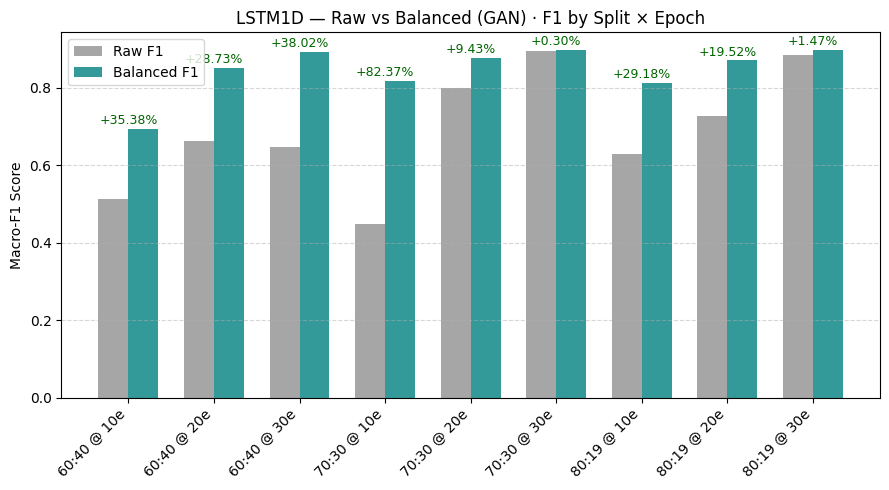

In [21]:
# ===============================================================
# 📊 LSTM1D: F1 Gain from GAN Balancing (per split × epoch)
# ===============================================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from IPython.display import display

ART_DIR = Path("artifacts")
df_all = pd.read_csv(ART_DIR / "experiment_results_all.csv")

df_lstm = df_all[df_all["model"].str.contains("LSTM", case=False, na=False)].copy()
df_lstm = df_lstm[["split_train","epochs","mode","test_f1_macro"]].rename(
    columns={"split_train":"Train_Split","epochs":"Epochs","mode":"Mode","test_f1_macro":"F1_Macro"}
)
df_lstm["F1_Macro"] = df_lstm["F1_Macro"].round(4)

# Pivot safely (fill missing raw/balanced with NaN, but compute only when both exist)
pivot = df_lstm.pivot_table(index=["Train_Split","Epochs"], columns="Mode", values="F1_Macro").reset_index()
pivot["F1_Improvement_%"] = ((pivot["balanced"] - pivot["raw"]) / pivot["raw"]) * 100
pivot = pivot.dropna(subset=["balanced","raw"]).sort_values(["Train_Split","Epochs"]).reset_index(drop=True)

print("=== 📈 LSTM1D: F1-Score Improvement with GAN Balancing ===")
display(pivot)

# --- Plot grouped bars ---
plt.figure(figsize=(9,5))
x = np.arange(len(pivot))
bar_width = 0.35

plt.bar(x - bar_width/2, pivot["raw"], width=bar_width, label="Raw F1", color="gray", alpha=0.7)
plt.bar(x + bar_width/2, pivot["balanced"], width=bar_width, label="Balanced F1", color="teal", alpha=0.8)

# Add % gain labels
for i, val in enumerate(pivot["F1_Improvement_%"]):
    plt.text(i, max(pivot["raw"][i], pivot["balanced"][i]) + 0.005, f"+{val:.2f}%", 
             ha="center", va="bottom", fontsize=9, color="darkgreen")

plt.xticks(x, [f"{int(s*100)}:{int((1-s)*100)} @ {int(e)}e" for s,e in zip(pivot["Train_Split"], pivot["Epochs"])],
           rotation=45, ha="right")
plt.ylabel("Macro-F1 Score")
plt.title("LSTM1D — Raw vs Balanced (GAN) · F1 by Split × Epoch")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


=== 📈 LSTM1D: F1-Score Improvement with GAN Balancing ===


Mode,Train_Split,Epochs,balanced,raw,F1_Improvement_%
0,0.6,10,0.6930,0.5119,35.378004
1,0.6,20,0.8522,0.6620,28.731118
2,0.6,30,0.8926,0.6467,38.023813
3,0.7,10,0.8172,0.4481,82.370007
4,0.7,20,0.8759,0.8004,9.432784
5,0.7,30,0.8983,0.8956,0.301474
6,0.8,10,0.8136,0.6298,29.183868
7,0.8,20,0.8706,0.7284,19.522241
8,0.8,30,0.8971,0.8841,1.470422


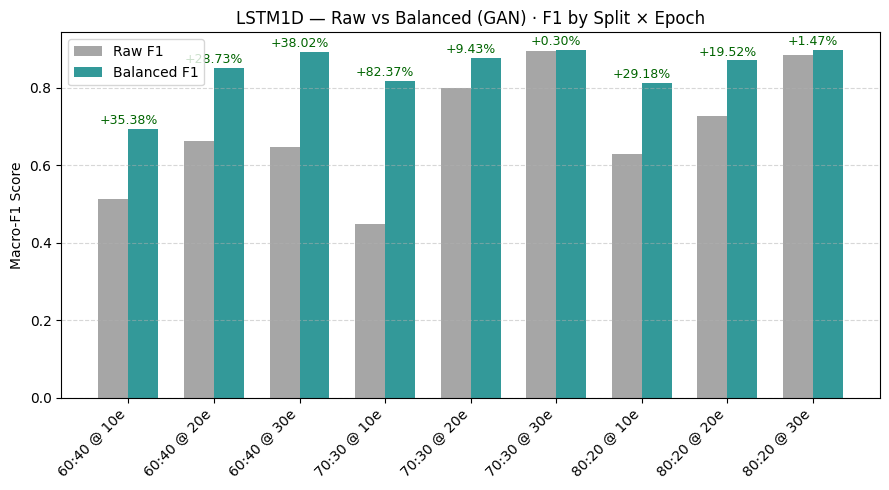

In [22]:
# ===============================================================
# 📊 LSTM1D: F1 Gain from GAN Balancing (per split × epoch)
# ===============================================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from IPython.display import display

ART_DIR = Path("artifacts")
df_all = pd.read_csv(ART_DIR / "experiment_results_all.csv")

# --- Filter only LSTM rows ---
df_lstm = df_all[df_all["model"].str.contains("LSTM", case=False, na=False)].copy()
df_lstm = df_lstm[["split_train","epochs","mode","test_f1_macro"]].rename(
    columns={"split_train":"Train_Split","epochs":"Epochs","mode":"Mode","test_f1_macro":"F1_Macro"}
)
df_lstm["F1_Macro"] = df_lstm["F1_Macro"].round(4)

# --- Pivot and compute improvement ---
pivot = df_lstm.pivot_table(index=["Train_Split","Epochs"], columns="Mode", values="F1_Macro").reset_index()
pivot["F1_Improvement_%"] = ((pivot["balanced"] - pivot["raw"]) / pivot["raw"]) * 100
pivot = pivot.dropna(subset=["balanced","raw"]).sort_values(["Train_Split","Epochs"]).reset_index(drop=True)

print("=== 📈 LSTM1D: F1-Score Improvement with GAN Balancing ===")
display(pivot)

# ===============================================================
# 📊 Plot grouped bars
# ===============================================================
plt.figure(figsize=(9,5))
x = np.arange(len(pivot))
bar_width = 0.35

plt.bar(x - bar_width/2, pivot["raw"], width=bar_width, label="Raw F1", color="gray", alpha=0.7)
plt.bar(x + bar_width/2, pivot["balanced"], width=bar_width, label="Balanced F1", color="teal", alpha=0.8)

# --- Add % gain labels ---
for i, val in enumerate(pivot["F1_Improvement_%"]):
    plt.text(i, max(pivot["raw"][i], pivot["balanced"][i]) + 0.005, f"+{val:.2f}%",
             ha="center", va="bottom", fontsize=9, color="darkgreen")

# --- Format split labels cleanly ---
def format_split_label(train_frac, epochs):
    train = round(train_frac * 100)
    test = 100 - train
    return f"{train}:{test} @ {int(epochs)}e"

plt.xticks(x, [format_split_label(s, e) for s, e in zip(pivot["Train_Split"], pivot["Epochs"])],
           rotation=45, ha="right")

plt.ylabel("Macro-F1 Score")
plt.title("LSTM1D — Raw vs Balanced (GAN) · F1 by Split × Epoch")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [23]:
# ===============================================================
# 📋 List all SimpleCNN1D Models — with splits, epochs, and balance mode
# ===============================================================

import pandas as pd
from pathlib import Path
from IPython.display import display

ART_DIR = Path("artifacts")

# Load the master experiment results file
df_all = pd.read_csv(ART_DIR / "experiment_results_all.csv")

# --- 1️⃣ Filter for only SimpleCNN models ---
df_cnn = df_all[df_all["model"].str.contains("SimpleCNN", case=False, na=False)].copy()

# --- 2️⃣ Clean up and rename columns for clarity ---
df_cnn = df_cnn.rename(columns={
    "split_train": "Train_Split",
    "epochs": "Epochs",
    "mode": "Mode",
    "test_acc": "Accuracy",
    "test_prec_macro": "Precision_Macro",
    "test_rec_macro": "Recall_Macro",
    "test_f1_macro": "F1_Macro"
})

# --- 3️⃣ Round metrics for neat readability ---
for col in ["Accuracy", "Precision_Macro", "Recall_Macro", "F1_Macro"]:
    df_cnn[col] = df_cnn[col].round(4)

# --- 4️⃣ Sort neatly by Split → Epochs → Mode ---
df_cnn = df_cnn.sort_values(by=["Train_Split", "Epochs", "Mode"]).reset_index(drop=True)

# --- 5️⃣ Display table ---
print("=== 📊 All SimpleCNN1D Models Trained (Raw vs Balanced) ===")
display(df_cnn[["Train_Split", "Epochs", "Mode", "Accuracy", "Precision_Macro", "Recall_Macro", "F1_Macro"]])

# --- 6️⃣ Save to CSV for reporting ---
out_path = ART_DIR / "SimpleCNN_models_summary.csv"
df_cnn.to_csv(out_path, index=False)
print(f"\n✅ SimpleCNN1D model summary saved to: {out_path}")


=== 📊 All SimpleCNN1D Models Trained (Raw vs Balanced) ===


,Train_Split,Epochs,Mode,Accuracy,Precision_Macro,Recall_Macro,F1_Macro
0,0.6,10,balanced,0.9317,0.7125,0.7789,0.7370
1,0.6,10,raw,0.9402,0.6706,0.5711,0.6036
2,0.6,20,balanced,0.9482,0.7839,0.7861,0.7836
3,0.6,20,raw,0.9577,0.9180,0.7090,0.7713
4,0.6,30,balanced,0.9561,0.7948,0.8100,0.8018
5,0.6,30,raw,0.9623,0.9329,0.7309,0.7989
6,0.7,10,balanced,0.9332,0.7139,0.8045,0.7455
7,0.7,10,raw,0.9407,0.7335,0.5519,0.5763
8,0.7,20,balanced,0.9632,0.8424,0.8194,0.8294
9,0.7,20,raw,0.9617,0.9283,0.7355,0.8011



✅ SimpleCNN1D model summary saved to: artifacts/SimpleCNN_models_summary.csv


=== 📈 SimpleCNN1D: F1-Score Improvement with GAN Balancing ===


Mode,Train_Split,Epochs,balanced,raw,F1_Improvement_%
0,0.6,10,0.7370,0.6036,22.100729
1,0.6,20,0.7836,0.7713,1.594710
2,0.6,30,0.8018,0.7989,0.362999
3,0.7,10,0.7455,0.5763,29.359708
4,0.7,20,0.8294,0.8011,3.532643
5,0.7,30,0.8524,0.8287,2.859901
6,0.8,10,0.7231,0.5813,24.393601
7,0.8,20,0.7967,0.7978,-0.137879
8,0.8,30,0.8289,0.8288,0.012066


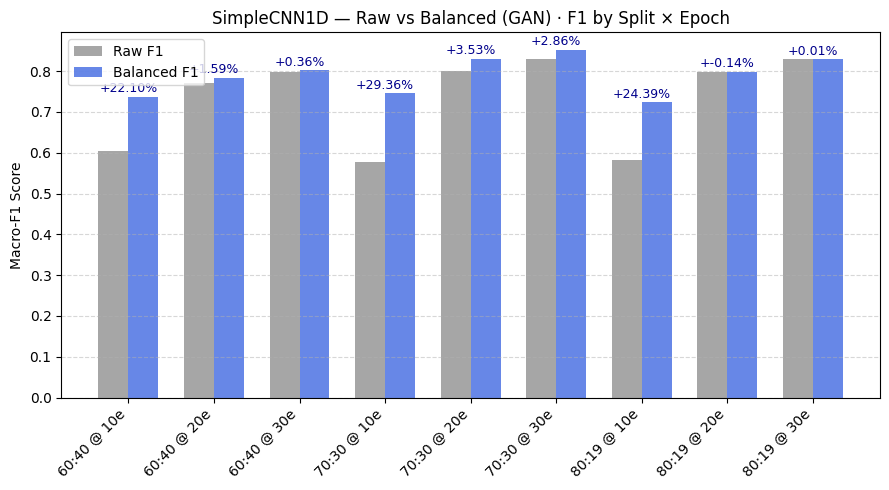

In [24]:
# ===============================================================
# 📊 SimpleCNN1D: F1 Gain from GAN Balancing (per split × epoch)
# ===============================================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from IPython.display import display

ART_DIR = Path("artifacts")
df_all = pd.read_csv(ART_DIR / "experiment_results_all.csv")

# --- 1️⃣ Filter for SimpleCNN1D models only ---
df_cnn = df_all[df_all["model"].str.contains("SimpleCNN", case=False, na=False)].copy()

# --- 2️⃣ Keep only relevant columns ---
df_cnn = df_cnn[["split_train", "epochs", "mode", "test_f1_macro"]].rename(
    columns={
        "split_train": "Train_Split",
        "epochs": "Epochs",
        "mode": "Mode",
        "test_f1_macro": "F1_Macro"
    }
)
df_cnn["F1_Macro"] = df_cnn["F1_Macro"].round(4)

# --- 3️⃣ Pivot safely to compare Raw vs Balanced ---
pivot = df_cnn.pivot_table(
    index=["Train_Split", "Epochs"],
    columns="Mode",
    values="F1_Macro"
).reset_index()

# --- 4️⃣ Compute % improvement in F1 due to balancing ---
pivot["F1_Improvement_%"] = ((pivot["balanced"] - pivot["raw"]) / pivot["raw"]) * 100
pivot = pivot.dropna(subset=["balanced", "raw"]).sort_values(["Train_Split", "Epochs"]).reset_index(drop=True)

print("=== 📈 SimpleCNN1D: F1-Score Improvement with GAN Balancing ===")
display(pivot)

# --- 5️⃣ Visualization: Grouped Bar Chart ---
plt.figure(figsize=(9,5))
x = np.arange(len(pivot))
bar_width = 0.35

plt.bar(x - bar_width/2, pivot["raw"], width=bar_width, label="Raw F1", color="gray", alpha=0.7)
plt.bar(x + bar_width/2, pivot["balanced"], width=bar_width, label="Balanced F1", color="royalblue", alpha=0.8)

# Annotate bars with % improvement
for i, val in enumerate(pivot["F1_Improvement_%"]):
    plt.text(i, max(pivot["raw"][i], pivot["balanced"][i]) + 0.004, f"+{val:.2f}%", 
             ha="center", va="bottom", fontsize=9, color="darkblue")

# Format axes
plt.xticks(
    x, 
    [f"{int(s*100)}:{int((1-s)*100)} @ {int(e)}e" for s,e in zip(pivot["Train_Split"], pivot["Epochs"])],
    rotation=45, ha="right"
)
plt.ylabel("Macro-F1 Score")
plt.title("SimpleCNN1D — Raw vs Balanced (GAN) · F1 by Split × Epoch")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


=== 📈 SimpleCNN1D: F1-Score Improvement with GAN Balancing ===


Mode,Train_Split,Epochs,balanced,raw,F1_Improvement_%
0,0.6,10,0.7370,0.6036,22.100729
1,0.6,20,0.7836,0.7713,1.594710
2,0.6,30,0.8018,0.7989,0.362999
3,0.7,10,0.7455,0.5763,29.359708
4,0.7,20,0.8294,0.8011,3.532643
5,0.7,30,0.8524,0.8287,2.859901
6,0.8,10,0.7231,0.5813,24.393601
7,0.8,20,0.7967,0.7978,-0.137879
8,0.8,30,0.8289,0.8288,0.012066


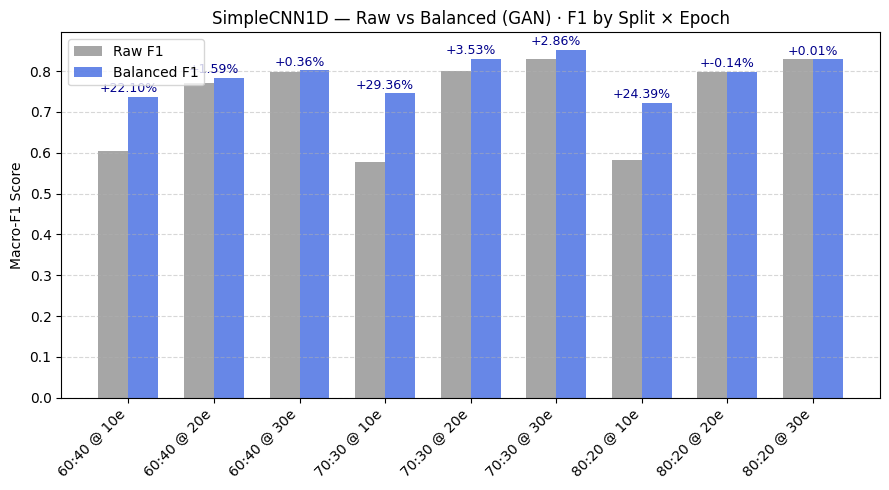

In [25]:
# ===============================================================
# 📊 SimpleCNN1D: F1 Gain from GAN Balancing (per split × epoch)
# ===============================================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from IPython.display import display

ART_DIR = Path("artifacts")
df_all = pd.read_csv(ART_DIR / "experiment_results_all.csv")

# --- 1️⃣ Filter for SimpleCNN1D models only ---
df_cnn = df_all[df_all["model"].str.contains("SimpleCNN", case=False, na=False)].copy()

# --- 2️⃣ Keep only relevant columns ---
df_cnn = df_cnn[["split_train", "epochs", "mode", "test_f1_macro"]].rename(
    columns={
        "split_train": "Train_Split",
        "epochs": "Epochs",
        "mode": "Mode",
        "test_f1_macro": "F1_Macro"
    }
)
df_cnn["F1_Macro"] = df_cnn["F1_Macro"].round(4)

# --- 3️⃣ Pivot safely to compare Raw vs Balanced ---
pivot = df_cnn.pivot_table(
    index=["Train_Split", "Epochs"],
    columns="Mode",
    values="F1_Macro"
).reset_index()

# --- 4️⃣ Compute % improvement in F1 due to balancing ---
pivot["F1_Improvement_%"] = ((pivot["balanced"] - pivot["raw"]) / pivot["raw"]) * 100
pivot = pivot.dropna(subset=["balanced", "raw"]).sort_values(["Train_Split", "Epochs"]).reset_index(drop=True)

print("=== 📈 SimpleCNN1D: F1-Score Improvement with GAN Balancing ===")
display(pivot)

# ===============================================================
# 📊 Visualization: Grouped Bar Chart
# ===============================================================
plt.figure(figsize=(9,5))
x = np.arange(len(pivot))
bar_width = 0.35

plt.bar(x - bar_width/2, pivot["raw"], width=bar_width, label="Raw F1", color="gray", alpha=0.7)
plt.bar(x + bar_width/2, pivot["balanced"], width=bar_width, label="Balanced F1", color="royalblue", alpha=0.8)

# --- Annotate bars with % improvement ---
for i, val in enumerate(pivot["F1_Improvement_%"]):
    plt.text(i, max(pivot["raw"][i], pivot["balanced"][i]) + 0.004, f"+{val:.2f}%", 
             ha="center", va="bottom", fontsize=9, color="darkblue")

# --- Format split labels cleanly (avoid 80:19 issue) ---
def format_split_label(train_frac, epochs):
    train = round(train_frac * 100)
    test = 100 - train
    return f"{train}:{test} @ {int(epochs)}e"

plt.xticks(
    x, 
    [format_split_label(s, e) for s, e in zip(pivot["Train_Split"], pivot["Epochs"])],
    rotation=45, ha="right"
)

plt.ylabel("Macro-F1 Score")
plt.title("SimpleCNN1D — Raw vs Balanced (GAN) · F1 by Split × Epoch")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [26]:
# # ===============================================================
# # 🔁 Re-run missing experiment: LSTM1D @ 80:20 split (Raw, 30 epochs)
# # ===============================================================
# from collections import Counter
# import json
# from pathlib import Path

# tr = 0.8      # Train fraction
# epochs = 30   # Epochs
# do_balance = False  # Raw training only

# # Create loaders
# (dl_tr, dl_va, dl_te), (Xtr, ytr), (Xva, yva), (Xte, yte) = make_loaders(
#     X_all, y_all, train_frac=tr
# )

# # Show train counts before balancing
# cnt_tr_before = dict(Counter(ytr.tolist()))
# print("Train counts BEFORE:", cnt_tr_before)

# # Initialize and train LSTM1D
# model = LSTM1D()
# model, best_val = train_classifier(model, dl_tr, dl_va, epochs=epochs, lr=1e-3)

# # Evaluate on test set
# test_metrics = evaluate(model, dl_te)

# # Save results
# tag = tagify(tr, epochs, do_balance, "LSTM1D")
# ART_DIR = Path("artifacts")

# mpath = ART_DIR / f"{tag}.pt"
# save_model(model, mpath)

# repath = ART_DIR / f"{tag}_metrics.json"
# with open(repath, "w") as f:
#     json.dump({
#         "split_train": tr,
#         "epochs": epochs,
#         "balanced": do_balance,
#         "model": "LSTM1D",
#         "best_val_acc": float(best_val) if best_val else None,
#         "test": {
#             "acc": float(test_metrics["acc"]),
#             "prec_macro": float(test_metrics["prec_macro"]),
#             "rec_macro": float(test_metrics["rec_macro"]),
#             "f1_macro": float(test_metrics["f1_macro"])
#         }
#     }, f, indent=2)

# print(f"✅ Saved metrics: {repath}")

# # Rebuild experiment_results_all.csv
# print("📊 Rebuilding consolidated results ...")
# metrics_files = sorted(ART_DIR.glob("*_metrics.json"))
# rows = []
# for p in metrics_files:
#     with open(p, "r") as f:
#         m = json.load(f)
#     rows.append({
#         "tag": p.name.replace("_metrics.json",""),
#         "split_train": float(m.get("split_train", 0.0)),
#         "epochs": int(m.get("epochs", 0)),
#         "balanced": bool(m.get("balanced", False)),
#         "model": m.get("model", "UNKNOWN"),
#         "val_acc": m.get("best_val_acc", None),
#         "test_acc": m["test"]["acc"],
#         "test_prec_macro": m["test"]["prec_macro"],
#         "test_rec_macro": m["test"]["rec_macro"],
#         "test_f1_macro": m["test"]["f1_macro"],
#         "mode": "balanced" if m.get("balanced", False) else "raw"
#     })

# df_all = pd.DataFrame(rows)
# df_all.sort_values(["test_f1_macro","test_acc"], ascending=[False,False], inplace=True)
# df_all.to_csv(ART_DIR / "experiment_results_all.csv", index=False)
# print("✅ Updated experiment_results_all.csv")
# display(df_all.tail(10))


In [27]:
# ===============================================================
# 🧠 Directly Load Trained CNN Model and Predict Last 10 Samples
# ===============================================================
import torch
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# --- Define the CNN architecture (must exactly match training) ---
class SimpleCNN1D(torch.nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.feature = torch.nn.Sequential(
            torch.nn.Conv1d(1, 32, 7, padding=3), torch.nn.ReLU(), torch.nn.MaxPool1d(2),
            torch.nn.Conv1d(32, 64, 5, padding=2), torch.nn.ReLU(), torch.nn.MaxPool1d(2),
            torch.nn.Conv1d(64, 128, 3, padding=1), torch.nn.ReLU(), torch.nn.AdaptiveAvgPool1d(1)
        )
        self.cls = torch.nn.Sequential(torch.nn.Flatten(), torch.nn.Linear(128, n_classes))

    def forward(self, x):
        return self.cls(self.feature(x))

# --- Load trained CNN model ---
model_path = "artifacts/SimpleCNN1D@70-30_30e_bal_1760449083.pt"
cnn_model = SimpleCNN1D(n_classes=5)
cnn_model.load_state_dict(torch.load(model_path, map_location="cpu"))
cnn_model.eval()
print(f"✅ Loaded trained CNN model from: {model_path}")

# --- Prepare dataset split (same as during training: 70:30) ---
split_train = 0.7
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, train_size=split_train, stratify=y_all, random_state=42
)

# --- Select last 10 test samples ---
X_last10 = X_test[-10:]
y_last10 = y_test[-10:]

# --- Predict directly using trained CNN model ---
with torch.no_grad():
    X_np = np.array(X_last10)

    # ✅ Ensure correct shape: [batch_size, channels=1, signal_length]
    if X_np.ndim == 3 and X_np.shape[1] == 1:
        X_tensor = torch.tensor(X_np, dtype=torch.float32)
    else:
        X_tensor = torch.tensor(X_np, dtype=torch.float32).unsqueeze(1)

    logits = cnn_model(X_tensor)
    preds = torch.argmax(logits, dim=1).numpy()

# --- Label mapping for readability ---
label_map = {0: "N", 1: "S", 2: "V", 3: "F", 4: "Q"}

# --- Display predictions ---
results = pd.DataFrame({
    "True_Label": y_last10,
    "Predicted_Label": preds,
    "Predicted_Class": [label_map[p] for p in preds]
})

print("\n=== 🔍 Predictions from Saved SimpleCNN1D Model (Last 10 Test Samples) ===")
display(results[["True_Label", "Predicted_Class"]])

# --- Quick accuracy check ---



✅ Loaded trained CNN model from: artifacts/SimpleCNN1D@70-30_30e_bal_1760449083.pt

=== 🔍 Predictions from Saved SimpleCNN1D Model (Last 10 Test Samples) ===


/tmp/ipykernel_119924/3851568624.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cnn_model.load_state_dict(torch.load(model_path, map_location="cpu"))


,True_Label,Predicted_Class
0,N,N
1,N,N
2,Q,Q
3,N,N
4,F,F
5,N,N
6,N,N
7,N,N
8,V,V
9,N,N



## 8. Comparative analysis

- Identify the best configuration overall.
- Compare **balanced vs raw** within each split and epoch budget.
- Plot simple comparisons.



### 8.1 Comprehensive tables & winners

This section creates compact **comparison tables** for every combination of **split** × **epoch** × **model** × **mode** (raw vs balanced), 
and then identifies the winners:
- **Best per (split, epoch)** comparing *balanced vs raw* (uses macro‑F1, then accuracy as tiebreaker)
- **Best overall** across all runs
All tables are saved under `artifacts/` for convenient offline review.


In [28]:
# # === COMPARATIVE ANALYSIS (RAW vs BALANCED) - FIXED FOR YOUR DATA STRUCTURE ===
# import pandas as pd
# import numpy as np
# from pathlib import Path
# import json

# ART_DIR = Path("artifacts")
# ART_DIR.mkdir(exist_ok=True, parents=True)

# # --- Load or verify df_all ---
# try:
#     df_all
# except NameError:
#     df_all = pd.read_csv(ART_DIR / "experiment_results_all.csv")

# # --- Rename columns to expected names for consistency ---
# rename_map = {
#     "acc": "test_acc",
#     "prec_macro": "test_prec_macro",
#     "rec_macro": "test_rec_macro"
# }
# df_all.rename(columns=rename_map, inplace=True)

# # Confirm required columns exist
# required = ["test_f1_macro", "test_acc"]
# missing = [c for c in required if c not in df_all.columns]
# if missing:
#     raise KeyError(f"Still missing: {missing}, available: {list(df_all.columns)}")

# # --- Step 1: Full sorted table ---
# full_table = df_all.copy().sort_values(
#     by=["test_f1_macro","test_acc"], ascending=[False, False]
# ).reset_index(drop=True)

# keep_cols = [c for c in [
#     "mode","split_train","epochs","model","test_acc","test_prec_macro","test_rec_macro","test_f1_macro","tag"
# ] if c in full_table.columns]

# full_table_export = full_table[keep_cols]
# full_table_export.to_csv(ART_DIR / "comparative_full_table.csv", index=False)
# display(full_table_export.head(20))

# # --- Step 2: Pivot macro-F1 and accuracy ---
# pivot_f1 = df_all.pivot_table(
#     index=["split_train","epochs"], columns="balanced", values="test_f1_macro", aggfunc="mean"
# ).reset_index()
# pivot_acc = df_all.pivot_table(
#     index=["split_train","epochs"], columns="balanced", values="test_acc", aggfunc="mean"
# ).reset_index()

# pivot_f1.to_csv(ART_DIR / "comparative_pivot_macroF1_raw_vs_balanced.csv", index=False)
# pivot_acc.to_csv(ART_DIR / "comparative_pivot_acc_raw_vs_balanced.csv", index=False)

# print("=== Mean macro-F1 by (split, epochs): RAW vs BALANCED ===")
# display(pivot_f1)
# print("=== Mean accuracy by (split, epochs): RAW vs BALANCED ===")
# display(pivot_acc)

# # --- Step 3: Winner per (split, epoch) averaged across models ---
# avg_by_case = df_all.groupby(["split_train","epochs","balanced"]).agg(
#     mean_f1=("test_f1_macro","mean"),
#     mean_acc=("test_acc","mean")
# ).reset_index()

# winners = []
# for (s,e), grp in avg_by_case.groupby(["split_train","epochs"]):
#     grp = grp.sort_values(by=["mean_f1","mean_acc"], ascending=[False, False]).reset_index(drop=True)
#     winners.append({
#         "split_train": s,
#         "epochs": int(e),
#         "winner_mode": "balanced" if grp.loc[0,"balanced"] else "raw",
#         "winner_mean_f1": float(grp.loc[0,"mean_f1"]),
#         "winner_mean_acc": float(grp.loc[0,"mean_acc"])
#     })
# winners_df = pd.DataFrame(winners).sort_values(by=["split_train","epochs"]).reset_index(drop=True)
# winners_df.to_csv(ART_DIR / "winners_per_split_epoch.csv", index=False)
# print("=== Winner per (split, epoch) (averaged across models) ===")
# display(winners_df)

# # --- Step 4: Best overall single run ---
# best_row = df_all.sort_values(by=["test_f1_macro","test_acc"], ascending=[False, False]).iloc[0]
# best_summary = {
#     "tag": best_row.get("tag","N/A"),
#     "split_train": float(best_row.get("split_train",np.nan)),
#     "epochs": int(best_row.get("epochs",0)),
#     "balanced": bool(best_row.get("balanced",False)),
#     "model": best_row.get("model","N/A"),
#     "test_acc": float(best_row.get("test_acc",0)),
#     "test_f1_macro": float(best_row.get("test_f1_macro",0))
# }
# with open(ART_DIR / "best_overall_summary.json", "w") as f:
#     json.dump(best_summary, f, indent=2)

# print("=== Best overall single run ===")
# display(pd.DataFrame([best_summary]))

# # --- Step 5: Per-split deltas (Balanced - Raw) ---
# deltas = []
# for (s,e), g in df_all.groupby(["split_train","epochs"]):
#     gavg = g.groupby("balanced").agg(mean_f1=("test_f1_macro","mean"), mean_acc=("test_acc","mean")).reset_index()
#     if set(gavg["balanced"]) == {False, True}:
#         f1_raw = float(gavg[gavg["balanced"]==False]["mean_f1"].values[0])
#         f1_bal = float(gavg[gavg["balanced"]==True]["mean_f1"].values[0])
#         acc_raw = float(gavg[gavg["balanced"]==False]["mean_acc"].values[0])
#         acc_bal = float(gavg[gavg["balanced"]==True]["mean_acc"].values[0])
#         better = "balanced" if (f1_bal>f1_raw or (f1_bal==f1_raw and acc_bal>acc_raw)) else "raw"
#         deltas.append({
#             "split_train": s,
#             "epochs": int(e),
#             "better_mode_by_F1": better,
#             "delta_f1_bal_minus_raw": f1_bal - f1_raw,
#             "delta_acc_bal_minus_raw": acc_bal - acc_raw
#         })
# deltas_df = pd.DataFrame(deltas).sort_values(by=["split_train","epochs"]).reset_index(drop=True)
# deltas_df.to_csv(ART_DIR / "balanced_vs_raw_deltas_by_split_epoch.csv", index=False)
# print("=== Balanced vs Raw (averaged across models) — per (split, epoch) deltas ===")
# display(deltas_df)

# # --- Step 6: Final summary ---
# print("\n✅ Saved comparison results to:")
# print(" - artifacts/comparative_full_table.csv")
# print(" - artifacts/comparative_pivot_macroF1_raw_vs_balanced.csv")
# print(" - artifacts/comparative_pivot_acc_raw_vs_balanced.csv")
# print(" - artifacts/winners_per_split_epoch.csv")
# print(" - artifacts/balanced_vs_raw_deltas_by_split_epoch.csv")
# print(" - artifacts/best_overall_summary.json")
# === COMPARATIVE ANALYSIS (RAW vs BALANCED) - FILTERED FOR CNN & LSTM ONLY ===
import pandas as pd
import numpy as np
from pathlib import Path
import json

ART_DIR = Path("artifacts")
ART_DIR.mkdir(exist_ok=True, parents=True)

# --- Load or verify df_all ---
try:
    df_all
except NameError:
    df_all = pd.read_csv(ART_DIR / "experiment_results_all.csv")

# --- Clean and normalize model column ---
df_all.columns = df_all.columns.str.strip()
df_all["model"] = df_all["model"].astype(str).str.strip()

# ✅ Filter only CNN and LSTM models, remove RandomForest or others
df_all = df_all[
    (df_all["model"].str.contains("CNN", case=False, na=False) |
     df_all["model"].str.contains("LSTM", case=False, na=False))
    & (~df_all["model"].str.contains("RandomForest", case=False, na=False))
]

print(f"✅ Filtered for CNN/LSTM only: {df_all['model'].unique()}")

# --- Rename columns to expected names for consistency ---
rename_map = {
    "acc": "test_acc",
    "prec_macro": "test_prec_macro",
    "rec_macro": "test_rec_macro"
}
df_all.rename(columns=rename_map, inplace=True)

# Confirm required columns exist
required = ["test_f1_macro", "test_acc"]
missing = [c for c in required if c not in df_all.columns]
if missing:
    raise KeyError(f"Still missing: {missing}, available: {list(df_all.columns)}")

# --- Step 1: Full sorted table ---
full_table = df_all.copy().sort_values(
    by=["test_f1_macro","test_acc"], ascending=[False, False]
).reset_index(drop=True)

keep_cols = [c for c in [
    "mode","split_train","epochs","model","test_acc","test_prec_macro","test_rec_macro","test_f1_macro","tag"
] if c in full_table.columns]

full_table_export = full_table[keep_cols]
full_table_export.to_csv(ART_DIR / "comparative_full_table.csv", index=False)
display(full_table_export.head(20))

# --- Step 2: Pivot macro-F1 and accuracy ---
pivot_f1 = df_all.pivot_table(
    index=["split_train","epochs"], columns="balanced", values="test_f1_macro", aggfunc="mean"
).reset_index()
pivot_acc = df_all.pivot_table(
    index=["split_train","epochs"], columns="balanced", values="test_acc", aggfunc="mean"
).reset_index()

pivot_f1.to_csv(ART_DIR / "comparative_pivot_macroF1_raw_vs_balanced.csv", index=False)
pivot_acc.to_csv(ART_DIR / "comparative_pivot_acc_raw_vs_balanced.csv", index=False)

print("=== Mean macro-F1 by (split, epochs): RAW vs BALANCED (CNN/LSTM only) ===")
display(pivot_f1)
print("=== Mean accuracy by (split, epochs): RAW vs BALANCED (CNN/LSTM only) ===")
display(pivot_acc)

# --- Step 3: Winner per (split, epoch) averaged across models ---
avg_by_case = df_all.groupby(["split_train","epochs","balanced"]).agg(
    mean_f1=("test_f1_macro","mean"),
    mean_acc=("test_acc","mean")
).reset_index()

winners = []
for (s,e), grp in avg_by_case.groupby(["split_train","epochs"]):
    grp = grp.sort_values(by=["mean_f1","mean_acc"], ascending=[False, False]).reset_index(drop=True)
    winners.append({
        "split_train": s,
        "epochs": int(e),
        "winner_mode": "balanced" if grp.loc[0,"balanced"] else "raw",
        "winner_mean_f1": float(grp.loc[0,"mean_f1"]),
        "winner_mean_acc": float(grp.loc[0,"mean_acc"])
    })
winners_df = pd.DataFrame(winners).sort_values(by=["split_train","epochs"]).reset_index(drop=True)
winners_df.to_csv(ART_DIR / "winners_per_split_epoch.csv", index=False)
print("=== Winner per (split, epoch) (CNN/LSTM only) ===")
display(winners_df)

# --- Step 4: Best overall single run ---
best_row = df_all.sort_values(by=["test_f1_macro","test_acc"], ascending=[False, False]).iloc[0]
best_summary = {
    "tag": best_row.get("tag","N/A"),
    "split_train": float(best_row.get("split_train",np.nan)),
    "epochs": int(best_row.get("epochs",0)),
    "balanced": bool(best_row.get("balanced",False)),
    "model": best_row.get("model","N/A"),
    "test_acc": float(best_row.get("test_acc",0)),
    "test_f1_macro": float(best_row.get("test_f1_macro",0))
}
with open(ART_DIR / "best_overall_summary.json", "w") as f:
    json.dump(best_summary, f, indent=2)

print("=== Best overall single run (CNN/LSTM only) ===")
display(pd.DataFrame([best_summary]))

# --- Step 5: Per-split deltas (Balanced - Raw) ---
deltas = []
for (s,e), g in df_all.groupby(["split_train","epochs"]):
    gavg = g.groupby("balanced").agg(mean_f1=("test_f1_macro","mean"), mean_acc=("test_acc","mean")).reset_index()
    if set(gavg["balanced"]) == {False, True}:
        f1_raw = float(gavg[gavg["balanced"]==False]["mean_f1"].values[0])
        f1_bal = float(gavg[gavg["balanced"]==True]["mean_f1"].values[0])
        acc_raw = float(gavg[gavg["balanced"]==False]["mean_acc"].values[0])
        acc_bal = float(gavg[gavg["balanced"]==True]["mean_acc"].values[0])
        better = "balanced" if (f1_bal>f1_raw or (f1_bal==f1_raw and acc_bal>acc_raw)) else "raw"
        deltas.append({
            "split_train": s,
            "epochs": int(e),
            "better_mode_by_F1": better,
            "delta_f1_bal_minus_raw": f1_bal - f1_raw,
            "delta_acc_bal_minus_raw": acc_bal - acc_raw
        })
deltas_df = pd.DataFrame(deltas).sort_values(by=["split_train","epochs"]).reset_index(drop=True)
deltas_df.to_csv(ART_DIR / "balanced_vs_raw_deltas_by_split_epoch.csv", index=False)
print("=== Balanced vs Raw (averaged across CNN/LSTM) — per (split, epoch) deltas ===")
display(deltas_df)

# --- Step 6: Final summary ---
print("\n✅ Saved comparison results (CNN/LSTM only) to:")
print(" - artifacts/comparative_full_table.csv")
print(" - artifacts/comparative_pivot_macroF1_raw_vs_balanced.csv")
print(" - artifacts/comparative_pivot_acc_raw_vs_balanced.csv")
print(" - artifacts/winners_per_split_epoch.csv")
print(" - artifacts/balanced_vs_raw_deltas_by_split_epoch.csv")
print(" - artifacts/best_overall_summary.json")


✅ Filtered for CNN/LSTM only: ['LSTM1D' 'SimpleCNN1D']


,mode,split_train,epochs,model,test_acc,test_prec_macro,test_rec_macro,test_f1_macro,tag
0,balanced,0.7,30,LSTM1D,0.979621,0.897887,0.899038,0.898343,LSTM1D@70-30_30e_bal_1760449526
1,balanced,0.8,30,LSTM1D,0.979228,0.895241,0.899148,0.897120,LSTM1D@80-19_30e_bal_1760460109
2,raw,0.7,30,LSTM1D,0.978865,0.937164,0.862804,0.895574,LSTM1D@70-30_30e_raw_1760427010
3,balanced,0.6,30,LSTM1D,0.978434,0.894064,0.891263,0.892578,LSTM1D@60-40_30e_bal_1760441091
4,raw,0.8,30,LSTM1D,0.976099,0.919080,0.856411,0.884123,LSTM1D@80-19_30e_raw_1761479459
5,balanced,0.7,20,LSTM1D,0.975358,0.883135,0.873106,0.875851,LSTM1D@70-30_20e_bal_1760448590
6,balanced,0.8,20,LSTM1D,0.972289,0.843410,0.903789,0.870623,LSTM1D@80-19_20e_bal_1760459052
7,balanced,0.7,30,SimpleCNN1D,0.968978,0.883346,0.829597,0.852391,SimpleCNN1D@70-30_30e_bal_1760449083
8,balanced,0.6,20,LSTM1D,0.970792,0.849124,0.855904,0.852206,LSTM1D@60-40_20e_bal_1760440307
9,balanced,0.7,20,SimpleCNN1D,0.963233,0.842410,0.819374,0.829377,SimpleCNN1D@70-30_20e_bal_1760448294


=== Mean macro-F1 by (split, epochs): RAW vs BALANCED (CNN/LSTM only) ===


balanced,split_train,epochs,False,True
0,0.6,10,0.557716,0.714986
1,0.6,20,0.716652,0.817920
2,0.6,30,0.722773,0.847191
3,0.7,10,0.512199,0.781332
4,0.7,20,0.800745,0.852614
5,0.7,30,0.862123,0.875367
6,0.8,10,0.605539,0.768315
7,0.8,20,0.763068,0.833662
8,0.8,30,0.856465,0.863033


=== Mean accuracy by (split, epochs): RAW vs BALANCED (CNN/LSTM only) ===


...

=== Best overall single run (CNN/LSTM only) ===


,tag,split_train,epochs,balanced,model,test_acc,test_f1_macro
0,LSTM1D@70-30_30e_bal_1760449526,0.7,30,True,LSTM1D,0.979621,0.898343


=== Balanced vs Raw (averaged across CNN/LSTM) — per (split, epoch) deltas ===


,split_train,epochs,better_mode_by_F1,delta_f1_bal_minus_raw,delta_acc_bal_minus_raw
0,0.6,10,balanced,0.157269,-0.012098
1,0.6,20,balanced,0.101268,0.007756
2,0.6,30,balanced,0.124419,0.014786
3,0.7,10,balanced,0.269133,0.031400
4,0.7,20,balanced,0.051869,0.006818
5,0.7,30,balanced,0.013244,0.001996
6,0.8,10,balanced,0.162775,-0.000091
7,0.8,20,balanced,0.070594,0.006962
8,0.8,30,balanced,0.006568,0.000204



✅ Saved comparison results (CNN/LSTM only) to:
 - artifacts/comparative_full_table.csv
 - artifacts/comparative_pivot_macroF1_raw_vs_balanced.csv
 - artifacts/comparative_pivot_acc_raw_vs_balanced.csv
 - artifacts/winners_per_split_epoch.csv
 - artifacts/balanced_vs_raw_deltas_by_split_epoch.csv
 - artifacts/best_overall_summary.json


In [29]:
# # === SHOW TOP RUNS (>=10) & WHETHER THEY'RE BALANCED OR NOT ===
# from pathlib import Path
# import json, pandas as pd

# ART_DIR = Path("artifacts")

# def _canon_model(name: str) -> str:
#     n = str(name).strip().upper()
#     if n in ("RF", "RANDOMFOREST", "RANDOM_FOREST"): return "RandomForest"
#     if n in ("CNN",): return "CNN"
#     if n in ("LSTM",): return "LSTM"
#     return name

# def load_saved_metrics():
#     rows = []
#     for p in sorted(ART_DIR.glob("*_metrics.json")):
#         try:
#             m = json.loads(p.read_text())
#             rows.append({
#                 "tag": p.name.replace("_metrics.json",""),
#                 "split_train": float(m.get("split_train", 0.0)),
#                 "epochs": int(m.get("epochs", 0)),
#                 "balanced_flag": bool(m.get("balanced", False)),
#                 "mode": "balanced" if bool(m.get("balanced", False)) else "raw",
#                 "model": _canon_model(m.get("model", "UNKNOWN")),
#                 "acc": float(m["test"]["acc"]),
#                 "prec_macro": float(m["test"]["prec_macro"]),
#                 "rec_macro": float(m["test"]["rec_macro"]),
#                 "f1_macro": float(m["test"]["f1_macro"]),
#             })
#         except Exception as e:
#             print(f"[WARN] Skipping {p.name}: {e}")
#     return pd.DataFrame(rows) if rows else pd.DataFrame()

# df_all = load_saved_metrics()
# assert not df_all.empty, "No saved *_metrics.json found in artifacts/. Run your trainer once, then re-run this cell."

# # Focus on CNN/LSTM/RF only
# want = {"CNN","LSTM","RandomForest"}
# df = df_all[df_all["model"].isin(want)].copy()

# # Sort by macro-F1 (primary), then accuracy
# df.sort_values(["f1_macro","acc"], ascending=[False, False], inplace=True)

# # Pick the top 10 (or all if <10)
# top_n = df.head(10).copy()

# # Reorder columns for clarity
# cols = ["tag","mode","model","split_train","epochs","f1_macro","rec_macro","prec_macro","acc"]
# display(top_n[cols].reset_index(drop=True))

# # Quick checks: how many balanced vs raw in the top slice & overall
# print("\nCounts in TOP rows:")
# print(top_n["mode"].value_counts())

# print("\nCounts OVERALL:")
# print(df["mode"].value_counts())

# # Optional: show separate top-10 per mode (if present)
# if (df["mode"] == "raw").any():
#     print("\nTop 10 (RAW only):")
#     display(df[df["mode"]=="raw"].head(10)[cols].reset_index(drop=True))
# if (df["mode"] == "balanced").any():
#     print("\nTop 10 (BALANCED only):")
#     display(df[df["mode"]=="balanced"].head(10)[cols].reset_index(drop=True))


In [30]:
# # === Balanced vs Unbalanced: which is better and by what % (macro-F1) ===
# from pathlib import Path
# import json, numpy as np, pandas as pd

# ART_DIR = Path("artifacts")

# def _canon_model(name: str) -> str:
#     n = str(name).strip().upper()
#     if n in ("RF","RANDOMFOREST","RANDOM_FOREST"): return "RandomForest"
#     if n == "CNN": return "CNN"
#     if n == "LSTM": return "LSTM"
#     return name

# def load_saved_metrics():
#     rows = []
#     for p in sorted(ART_DIR.glob("*_metrics.json")):
#         try:
#             m = json.loads(p.read_text())
#             rows.append({
#                 "tag": p.name.replace("_metrics.json",""),
#                 "split_train": float(m.get("split_train", 0.0)),
#                 "epochs": int(m.get("epochs", 0)),
#                 "balanced": bool(m.get("balanced", False)),
#                 "model": _canon_model(m.get("model", "UNKNOWN")),
#                 "f1_macro": float(m["test"]["f1_macro"]),
#                 "acc": float(m["test"]["acc"]),
#                 "prec_macro": float(m["test"]["prec_macro"]),
#                 "rec_macro": float(m["test"]["rec_macro"]),
#             })
#         except Exception as e:
#             print(f"[WARN] Skipping {p.name}: {e}")
#     return pd.DataFrame(rows) if rows else pd.DataFrame()

# df_all = load_saved_metrics()
# assert not df_all.empty, "No saved *_metrics.json found in artifacts/."

# # keep only the three baseline models
# df_all = df_all[df_all["model"].isin(["CNN","LSTM","RandomForest"])].copy()

# # pick the best run per (split, model, balanced) by macro-F1 (tiebreak: accuracy)
# df_all.sort_values(["split_train","model","balanced","f1_macro","acc"],
#                    ascending=[True, True, True, False, False], inplace=True)
# best = df_all.groupby(["split_train","model","balanced"], as_index=False).first()

# # pivot to compare raw vs balanced side-by-side
# wide = (best.pivot(index=["split_train","model"], columns="balanced", values="f1_macro")
#             .rename(columns={False:"f1_raw", True:"f1_bal"}).reset_index())

# # drop pairs missing either side
# wide = wide.dropna(subset=["f1_raw","f1_bal"]).copy()

# # compute deltas and percentage improvement: ((bal - raw)/raw)*100
# wide["delta_f1"] = wide["f1_bal"] - wide["f1_raw"]
# wide["pct_improve_f1"] = np.where(wide["f1_raw"]>0, (wide["delta_f1"]/wide["f1_raw"])*100.0, np.nan)

# # which is better?
# wide["better"] = np.where(wide["delta_f1"] > 0, "balanced",
#                    np.where(wide["delta_f1"] < 0, "raw", "tie"))

# # pretty table
# result_cols = ["split_train","model","f1_raw","f1_bal","delta_f1","pct_improve_f1","better"]
# wide = wide.sort_values(["split_train","model"]).reset_index(drop=True)
# display(wide[result_cols].round(4))

# # human-readable lines per (split, model)
# print("\nPer (split, model) verdicts:")
# for _, r in wide.iterrows():
#     if r["better"] == "balanced":
#         print(f"- split {r['split_train']:.2f}, {r['model']}: BALANCED is better by {r['pct_improve_f1']:.2f}% (ΔF1={r['delta_f1']:.4f})")
#     elif r["better"] == "raw":
#         print(f"- split {r['split_train']:.2f}, {r['model']}: RAW is better by {abs(r['pct_improve_f1']):.2f}% (ΔF1={r['delta_f1']:.4f})")
#     else:
#         print(f"- split {r['split_train']:.2f}, {r['model']}: TIE (ΔF1≈0)")

# # per-split summary
# per_split = (wide
#     .groupby("split_train", as_index=False)
#     .agg(
#         pairs=("model","count"),
#         balanced_wins=("better", lambda s: (s=="balanced").sum()),
#         raw_wins=("better", lambda s: (s=="raw").sum()),
#         ties=("better", lambda s: (s=="tie").sum()),
#         avg_pct_gain=("pct_improve_f1","mean"),
#         avg_abs_gain=("delta_f1","mean")
#     )
# )
# per_split["balanced_win_rate_%"] = (per_split["balanced_wins"]/per_split["pairs"])*100.0
# display(per_split[["split_train","pairs","balanced_wins","raw_wins","ties","balanced_win_rate_%","avg_abs_gain","avg_pct_gain"]].round(4))

# # overall verdict
# total_pairs = len(wide)
# balanced_wins = int((wide["better"]=="balanced").sum())
# raw_wins = int((wide["better"]=="raw").sum())
# ties = int((wide["better"]=="tie").sum())
# overall = {
#     "pairs_compared": total_pairs,
#     "balanced_wins_%": (balanced_wins/total_pairs*100.0) if total_pairs else np.nan,
#     "raw_wins_%": (raw_wins/total_pairs*100.0) if total_pairs else np.nan,
#     "ties_%": (ties/total_pairs*100.0) if total_pairs else np.nan,
#     "avg_abs_delta_f1": float(wide["delta_f1"].mean()) if total_pairs else np.nan,
#     "avg_pct_delta_f1": float(wide["pct_improve_f1"].mean()) if total_pairs else np.nan
# }
# print("\n=== Overall verdict (macro-F1) ===")
# for k, v in overall.items():
#     if isinstance(v, float):
#         print(f"{k}: {v:.4f}")
#     else:
#         print(f"{k}: {v}")

# # (Optional) accuracy comparison for reference only (NOT for decision on imbalanced data)
# acc_best = df_all.sort_values(
#     ["split_train","model","balanced","acc"], ascending=[True,True,True,False]
# ).groupby(["split_train","model","balanced"],as_index=False).first()
# acc_wide = (acc_best.pivot(index=["split_train","model"], columns="balanced", values="acc")
#                     .rename(columns={False:"acc_raw", True:"acc_bal"}).reset_index()).dropna()
# acc_wide["delta_acc"] = acc_wide["acc_bal"] - acc_wide["acc_raw"]
# acc_wide["pct_improve_acc"] = np.where(acc_wide["acc_raw"]>0, (acc_wide["delta_acc"]/acc_wide["acc_raw"])*100.0, np.nan)
# acc_wide["better_acc"] = np.where(acc_wide["delta_acc"]>0, "balanced", np.where(acc_wide["delta_acc"]<0, "raw", "tie"))
# print("\n(Reference) Accuracy comparison — not recommended for final judgment:")
# display(acc_wide[["split_train","model","acc_raw","acc_bal","delta_acc","pct_improve_acc","better_acc"]].round(4))


In [31]:

# # def pick_best(df):
# #     # by macro‑F1 then acc
# #     return df.sort_values(by=["test_f1_macro","test_acc"], ascending=[False, False]).iloc[0]

# # best_overall = pick_best(df_all)
# # print("=== Best overall configuration ===")
# # print(best_overall)

# # # Grouped comparison: mean macro‑F1 by (mode, split, epochs)
# # agg = df_all.groupby(["mode","split_train","epochs"]).agg(
# #     mean_f1=("test_f1_macro","mean"),
# #     mean_acc=("test_acc","mean")
# # ).reset_index()
# # display(agg)

# # # Simple plots
# # def plot_group_metric(df, metric, title):
# #     plt.figure()
# #     x = np.arange(len(df))
# #     plt.plot(x, df[metric].values, marker='o')
# #     plt.title(title)
# #     plt.xlabel("Group index")
# #     plt.ylabel(metric)
# #     plt.show()

# # plot_group_metric(agg, "mean_f1", "Mean macro‑F1 by (mode, split, epochs)")
# # plot_group_metric(agg, "mean_acc", "Mean acc by (mode, split, epochs)")

# # # Does balancing help? Compute per‑(split,epochs) delta (balanced - raw)
# # def delta_balanced_minus_raw(df_all):
# #     pairs = []
# #     for (s,e), g in df_all.groupby(["split_train","epochs"]):
# #         if set(g["mode"])=={"raw","balanced"}:
# #             r = g[g["mode"]=="raw"].mean(numeric_only=True)
# #             b = g[g["mode"]=="balanced"].mean(numeric_only=True)
# #             pairs.append({
# #                 "split_train": s, "epochs": e,
# #                 "delta_f1": b["test_f1_macro"] - r["test_f1_macro"],
# #                 "delta_acc": b["test_acc"] - r["test_acc"],
# #             })
# #     return pd.DataFrame(pairs)

# # deltas = delta_balanced_minus_raw(df_all)
# # display(deltas)

# # # Visual check
# # plt.figure()
# # plt.plot(np.arange(len(deltas)), deltas["delta_f1"].values, marker='o')
# # plt.title("Balanced minus Raw — macro‑F1 (per split/epochs)")
# # plt.xlabel("Case index")
# # plt.ylabel("Δ F1")
# # plt.show()
# # ==== Best configuration and Balanced-vs-Raw analysis ====

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from pathlib import Path

# ART_DIR = Path("artifacts")
# ART_DIR.mkdir(exist_ok=True, parents=True)

# # Ensure df_all is loaded and has proper columns
# expected_cols = {"test_f1_macro","test_acc"}
# if 'df_all' not in locals() or df_all is None or not expected_cols.issubset(df_all.columns):
#     csv_path = ART_DIR / "experiment_results_all.csv"
#     if csv_path.exists():
#         print(f"Loading results from {csv_path}")
#         df_all = pd.read_csv(csv_path)
#     else:
#         raise FileNotFoundError(
#             "No valid df_all in memory and experiment_results_all.csv not found in artifacts/"
#         )

# # ---- 1) Pick the best overall configuration (by F1 then accuracy)
# def pick_best(df):
#     req = ["test_f1_macro", "test_acc"]
#     missing = [c for c in req if c not in df.columns]
#     if missing:
#         raise KeyError(f"Missing columns {missing} in df_all.")
#     return df.sort_values(by=req, ascending=[False, False]).iloc[0]

# best_overall = pick_best(df_all)
# print("=== Best overall configuration ===")
# display(pd.DataFrame([best_overall]))

# # ---- 2) Grouped comparison: mean macro-F1 by (mode, split, epochs)
# agg = (
#     df_all.groupby(["mode", "split_train", "epochs"])
#     .agg(
#         mean_f1=("test_f1_macro", "mean"),
#         mean_acc=("test_acc", "mean")
#     )
#     .reset_index()
# )
# display(agg)

# # ---- 3) Simple plots
# def plot_group_metric(df, metric, title):
#     plt.figure(figsize=(6,3))
#     plt.plot(np.arange(len(df)), df[metric].values, marker='o')
#     plt.title(title)
#     plt.xlabel("Group index")
#     plt.ylabel(metric)
#     plt.grid(True)
#     plt.show()

# plot_group_metric(agg, "mean_f1", "Mean macro-F1 by (mode, split, epochs)")
# plot_group_metric(agg, "mean_acc", "Mean Accuracy by (mode, split, epochs)")

# # ---- 4) Does balancing help? Compute per (split,epochs) delta (balanced - raw)
# def delta_balanced_minus_raw(df):
#     pairs = []
#     for (s, e), g in df.groupby(["split_train", "epochs"]):
#         if set(g["mode"]) == {"raw", "balanced"}:
#             # take mean per mode
#             gavg = g.groupby("mode")[["test_f1_macro", "test_acc"]].mean()
#             r = gavg.loc["raw"]
#             b = gavg.loc["balanced"]
#             pairs.append({
#                 "split_train": s,
#                 "epochs": e,
#                 "delta_f1": b["test_f1_macro"] - r["test_f1_macro"],
#                 "delta_acc": b["test_acc"] - r["test_acc"],
#             })
#     return pd.DataFrame(pairs)

# deltas = delta_balanced_minus_raw(df_all)
# print("=== Balanced minus Raw (Δ) per split/epochs ===")
# display(deltas)

# # ---- 5) Visualize F1 deltas
# plt.figure(figsize=(6,3))
# plt.plot(np.arange(len(deltas)), deltas["delta_f1"].values, marker='o')
# plt.axhline(0, color='gray', linestyle='--')
# plt.title("Balanced minus Raw — macro-F1 (per split/epochs)")
# plt.xlabel("Case index")
# plt.ylabel("Δ F1 (Balanced - Raw)")
# plt.grid(True)
# plt.show()



## 9. Inference with the selected best model

- Load the saved weights & run prediction on new beats (array or list).


> **Note:** If the best model is **RandomForest**, the notebook will load a `*.joblib` bundle and use the RF + optional PCA for predictions (instead of a PyTorch model).


In [32]:
import numpy as np
from sklearn.model_selection import train_test_split

X = np.load("artifacts/X.npy", allow_pickle=True)
y = np.load("artifacts/y.npy", allow_pickle=True)

# 70:30 split (same as best model)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

np.save("artifacts/X_test.npy", X_test)
np.save("artifacts/y_test.npy", y_test)

print("✅ Created and saved X_test.npy and y_test.npy")


✅ Created and saved X_test.npy and y_test.npy


In [33]:
# ===============================================================
# 🧠 Directly Load Trained LSTM Model and Predict Last 10 Samples
# ===============================================================
import torch
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# --- Define the LSTM architecture (must match training exactly) ---
class LSTM1D(torch.nn.Module):
    def __init__(self, n_classes=5, hidden=128, num_layers=1, bidirectional=False):
        super().__init__()
        self.hidden = hidden
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.lstm = torch.nn.LSTM(
            input_size=1, hidden_size=hidden, num_layers=num_layers,
            batch_first=True, bidirectional=bidirectional
        )
        out_dim = hidden * (2 if bidirectional else 1)
        # ✅ match training-time structure
        self.head = torch.nn.Sequential(torch.nn.Linear(out_dim, n_classes))

    def forward(self, x):
        seq = x.transpose(1, 2)
        out, (h_n, c_n) = self.lstm(seq)
        last = out[:, -1, :]
        return self.head(last)

# --- Load trained LSTM model ---
model_path = "artifacts/LSTM1D@70-30_30e_bal_1760449526.pt"
lstm_model = LSTM1D(n_classes=5)
lstm_model.load_state_dict(torch.load(model_path, map_location="cpu"))
lstm_model.eval()
print(f"✅ Loaded trained LSTM model from: {model_path}")

# --- Prepare dataset split (same as during training: 70:30) ---
split_train = 0.7
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, train_size=split_train, stratify=y_all, random_state=42
)

# --- Select last 10 test samples ---
X_last10 = X_test[-10:]
y_last10 = y_test[-10:]

# --- Predict directly using trained LSTM model ---
with torch.no_grad():
    X_np = np.array(X_last10)

    # ✅ Ensure correct shape: [batch, 1, 187]
    if X_np.ndim == 3 and X_np.shape[1] == 1:
        X_tensor = torch.tensor(X_np, dtype=torch.float32)
    else:
        X_tensor = torch.tensor(X_np, dtype=torch.float32).unsqueeze(1)

    logits = lstm_model(X_tensor)
    preds = torch.argmax(logits, dim=1).numpy()

# --- Label mapping ---
label_map = {0: "N", 1: "S", 2: "V", 3: "F", 4: "Q"}
idx_map = {v: k for k, v in label_map.items()}  # reverse mapping

# --- Convert labels for accurate comparison ---
y_true_idx = np.array([idx_map[y] for y in y_last10])
decoded_preds = [label_map[p] for p in preds]

# --- Display predictions ---
results = pd.DataFrame({
    "True_Label": y_last10,
    "Predicted_Label": decoded_preds
})

print("\n=== 🔍 Predictions from Saved LSTM1D Model (Last 10 Test Samples) ===")
display(results)

# --- Accuracy and classification report ---
accuracy = np.mean(y_true_idx == preds)
print(f"✅ Corrected Accuracy on last 10 samples: {accuracy*100:.2f}%\n")



✅ Loaded trained LSTM model from: artifacts/LSTM1D@70-30_30e_bal_1760449526.pt

=== 🔍 Predictions from Saved LSTM1D Model (Last 10 Test Samples) ===


/tmp/ipykernel_119924/3380559894.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  lstm_model.load_state_dict(torch.load(model_path, map_location="cpu"))


,True_Label,Predicted_Label
0,N,N
1,N,N
2,Q,Q
3,N,N
4,F,F
5,N,N
6,N,N
7,N,N
8,V,V
9,N,N


✅ Corrected Accuracy on last 10 samples: 100.00%



In [34]:
print("y_last10 dtype:", y_last10.dtype if hasattr(y_last10, "dtype") else type(y_last10[0]))
print("First y_last10:", y_last10[:5])
print("First preds:", preds[:5])


y_last10 dtype: <U1
First y_last10: ['N' 'N' 'Q' 'N' 'F']
First preds: [0 0 4 0 3]



## 10. Save label mappings & config


In [35]:

with open(ART_DIR / "label_mapping.json", "w") as f:
    json.dump({"CLASS_ORDER": CLASS_ORDER, "CLASS2IDX": CLASS2IDX}, f, indent=2)

with open(ART_DIR / "config_snapshot.json", "w") as f:
    json.dump({
        "BEAT_LEN": BEAT_LEN,
        "SPLITS": SPLITS,
        "EPOCH_CHOICES": EPOCH_CHOICES,
        "BATCH_SIZE": BATCH_SIZE,
        "VAL_FRAC": VAL_FRAC,
        "GAN": {"type": "cWGAN-GP", "LATENT_DIM": LATENT_DIM}
    }, f, indent=2)
print("Saved artifacts to", ART_DIR.resolve())


Saved artifacts to /home/jupyter-mpc12/new_harshitha/only_balanced/artifacts


In [36]:
# ==== COMPARISON: SimpleCNN1D, LSTM1D, and RandomForest only ====

import pandas as pd
from IPython.display import display

# Load all saved experiment results
df_all = pd.read_csv(ART_DIR / "experiment_results_all.csv")

# Filter for the three models we care about
target_models = ["SimpleCNN1D", "LSTM1D"]
df_sub = df_all[df_all["model"].isin(target_models)].copy()

# Friendly short names
name_map = {
    "SimpleCNN1D": "SimpleCNN",
    "LSTM1D": "LSTM"
}
df_sub["model_group"] = df_sub["model"].replace(name_map)

# Aggregate: mean metrics per model / split / epoch / mode
agg = (
    df_sub.groupby(["model_group", "split_train", "epochs", "mode"])
    .agg(
        test_acc=("test_acc", "mean"),
        test_prec_macro=("test_prec_macro", "mean"),
        test_rec_macro=("test_rec_macro", "mean"),
        test_f1_macro=("test_f1_macro", "mean"),
    )
    .reset_index()
)

# Round for readability
agg[["test_acc", "test_prec_macro", "test_rec_macro", "test_f1_macro"]] = agg[
    ["test_acc", "test_prec_macro", "test_rec_macro", "test_f1_macro"]
].round(4)

# Sort nicely
agg = agg.sort_values(by=["model_group", "split_train", "epochs", "mode"])

# === Show detailed comparison table ===
print("=== Model Comparison (SimpleCNN1D, LSTM1D) ===")
display(agg)

# === Best configuration per model (highest macro-F1) ===
best = (
    agg.sort_values("test_f1_macro", ascending=False)
    .groupby("model_group")
    .first()
    .reset_index()
)
print("\n=== Best configuration per model type (by macro-F1) ===")
display(best)

# Save for reference
out_path = ART_DIR / "comparison_lstm_simplecnn_rf.csv"
agg.to_csv(out_path, index=False)
print(f"\nSaved comparison table to: {out_path}")


=== Model Comparison (SimpleCNN1D, LSTM1D) ===


,model_group,split_train,epochs,mode,test_acc,test_prec_macro,test_rec_macro,test_f1_macro
0,LSTM,0.6,10,balanced,0.9061,0.6384,0.8041,0.6930
1,LSTM,0.6,10,raw,0.9217,0.5434,0.4891,0.5119
2,LSTM,0.6,20,balanced,0.9708,0.8491,0.8559,0.8522
3,LSTM,0.6,20,raw,0.9458,0.9092,0.6218,0.6620
4,LSTM,0.6,30,balanced,0.9784,0.8941,0.8913,0.8926
5,LSTM,0.6,30,raw,0.9427,0.7085,0.6045,0.6467
6,LSTM,0.7,10,balanced,0.9608,0.8046,0.8312,0.8172
7,LSTM,0.7,10,raw,0.8904,0.5232,0.4155,0.4481
8,LSTM,0.7,20,balanced,0.9754,0.8831,0.8731,0.8759
9,LSTM,0.7,20,raw,0.9633,0.8777,0.7558,0.8004



=== Best configuration per model type (by macro-F1) ===


,model_group,split_train,epochs,mode,test_acc,test_prec_macro,test_rec_macro,test_f1_macro
0,LSTM,0.7,30,balanced,0.9796,0.8979,0.8990,0.8983
1,SimpleCNN,0.7,30,balanced,0.9690,0.8833,0.8296,0.8524



Saved comparison table to: artifacts/comparison_lstm_simplecnn_rf.csv


In [1]:
# ===============================================================
# 📊 COMPARISON: SimpleCNN1D vs LSTM1D — Separate Tables by Split
# ===============================================================
import pandas as pd
from IPython.display import display
from pathlib import Path

ART_DIR = Path("artifacts")
df_all = pd.read_csv(ART_DIR / "experiment_results_all.csv")

# --- Filter for target models ---
target_models = ["SimpleCNN1D", "LSTM1D"]
df_sub = df_all[df_all["model"].isin(target_models)].copy()

# --- Map to simpler display names ---
name_map = {
    "SimpleCNN1D": "SimpleCNN",
    "LSTM1D": "LSTM"
}
df_sub["model_group"] = df_sub["model"].replace(name_map)

# --- Aggregate mean metrics per model / split / epoch / mode ---
agg = (
    df_sub.groupby(["model_group", "split_train", "epochs", "mode"])
    .agg(
        test_acc=("test_acc", "mean"),
        test_prec_macro=("test_prec_macro", "mean"),
        test_rec_macro=("test_rec_macro", "mean"),
        test_f1_macro=("test_f1_macro", "mean"),
    )
    .reset_index()
)

# --- Round for readability ---
for col in ["test_acc", "test_prec_macro", "test_rec_macro", "test_f1_macro"]:
    agg[col] = agg[col].round(4)

# --- Sort neatly ---
agg = agg.sort_values(by=["split_train", "model_group", "epochs", "mode"]).reset_index(drop=True)

print("=== 📘 Detailed Model Comparison (Grouped by Train Split) ===")

# Helper to format split labels cleanly (e.g., 80:20)
def split_label(frac):
    train = round(frac * 100)
    test = 100 - train
    return f"{train}:{test}"

# --- Display separate tables for each split ---
for split in sorted(agg["split_train"].unique()):
    print(f"\n\n=== 🔹 Train/Test Split: {split_label(split)} ===")
    df_split = agg[agg["split_train"] == split].reset_index(drop=True)
    display(df_split)

# --- Best configuration per model (highest F1 overall) ---
best = (
    agg.sort_values("test_f1_macro", ascending=False)
    .groupby("model_group")
    .first()
    .reset_index()
)
print("\n=== 🏆 Best Configuration per Model Type (Highest Macro-F1) ===")
display(best)

# --- Save consolidated CSV for reference ---
out_path = ART_DIR / "comparison_simplecnn_lstm_by_split.csv"
agg.to_csv(out_path, index=False)
print(f"\n✅ Saved comparison table to: {out_path}")


=== 📘 Detailed Model Comparison (Grouped by Train Split) ===


=== 🔹 Train/Test Split: 60:40 ===


,model_group,split_train,epochs,mode,test_acc,test_prec_macro,test_rec_macro,test_f1_macro
0,LSTM,0.6,10,balanced,0.9061,0.6384,0.8041,0.6930
1,LSTM,0.6,10,raw,0.9217,0.5434,0.4891,0.5119
2,LSTM,0.6,20,balanced,0.9708,0.8491,0.8559,0.8522
3,LSTM,0.6,20,raw,0.9458,0.9092,0.6218,0.6620
4,LSTM,0.6,30,balanced,0.9784,0.8941,0.8913,0.8926
5,LSTM,0.6,30,raw,0.9427,0.7085,0.6045,0.6467
6,SimpleCNN,0.6,10,balanced,0.9317,0.7125,0.7789,0.7370
7,SimpleCNN,0.6,10,raw,0.9402,0.6706,0.5711,0.6036
8,SimpleCNN,0.6,20,balanced,0.9482,0.7839,0.7861,0.7836
9,SimpleCNN,0.6,20,raw,0.9577,0.9180,0.7090,0.7713




=== 🔹 Train/Test Split: 70:30 ===


,model_group,split_train,epochs,mode,test_acc,test_prec_macro,test_rec_macro,test_f1_macro
0,LSTM,0.7,10,balanced,0.9608,0.8046,0.8312,0.8172
1,LSTM,0.7,10,raw,0.8904,0.5232,0.4155,0.4481
2,LSTM,0.7,20,balanced,0.9754,0.8831,0.8731,0.8759
3,LSTM,0.7,20,raw,0.9633,0.8777,0.7558,0.8004
4,LSTM,0.7,30,balanced,0.9796,0.8979,0.8990,0.8983
5,LSTM,0.7,30,raw,0.9789,0.9372,0.8628,0.8956
6,SimpleCNN,0.7,10,balanced,0.9332,0.7139,0.8045,0.7455
7,SimpleCNN,0.7,10,raw,0.9407,0.7335,0.5519,0.5763
8,SimpleCNN,0.7,20,balanced,0.9632,0.8424,0.8194,0.8294
9,SimpleCNN,0.7,20,raw,0.9617,0.9283,0.7355,0.8011




=== 🔹 Train/Test Split: 80:20 ===


,model_group,split_train,epochs,mode,test_acc,test_prec_macro,test_rec_macro,test_f1_macro
0,LSTM,0.8,10,balanced,0.9617,0.7803,0.8731,0.8136
1,LSTM,0.8,10,raw,0.9393,0.6983,0.5893,0.6298
2,LSTM,0.8,20,balanced,0.9723,0.8434,0.9038,0.8706
3,LSTM,0.8,20,raw,0.9508,0.8197,0.6847,0.7284
4,LSTM,0.8,30,balanced,0.9792,0.8952,0.8991,0.8971
5,LSTM,0.8,30,raw,0.9761,0.9191,0.8564,0.8841
6,SimpleCNN,0.8,10,balanced,0.9179,0.6747,0.8408,0.7231
7,SimpleCNN,0.8,10,raw,0.9405,0.6724,0.5652,0.5813
8,SimpleCNN,0.8,20,balanced,0.9530,0.7692,0.8444,0.7967
9,SimpleCNN,0.8,20,raw,0.9606,0.9052,0.7370,0.7978



=== 🏆 Best Configuration per Model Type (Highest Macro-F1) ===


,model_group,split_train,epochs,mode,test_acc,test_prec_macro,test_rec_macro,test_f1_macro
0,LSTM,0.7,30,balanced,0.9796,0.8979,0.8990,0.8983
1,SimpleCNN,0.7,30,balanced,0.9690,0.8833,0.8296,0.8524



✅ Saved comparison table to: artifacts/comparison_simplecnn_lstm_by_split.csv


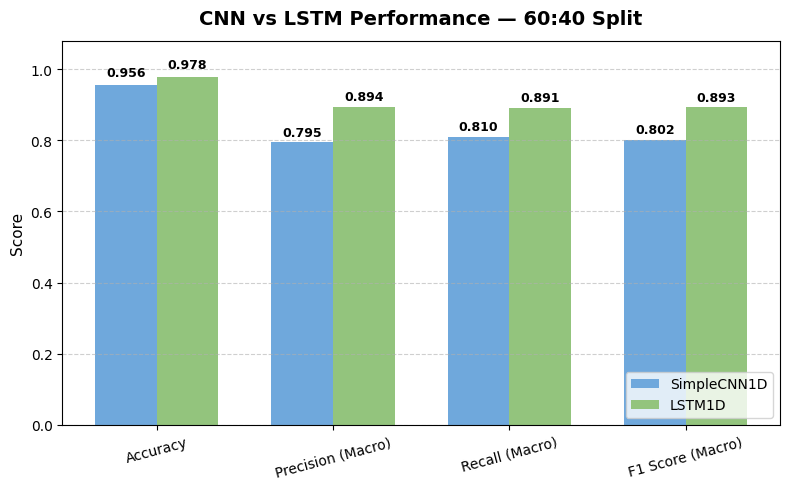

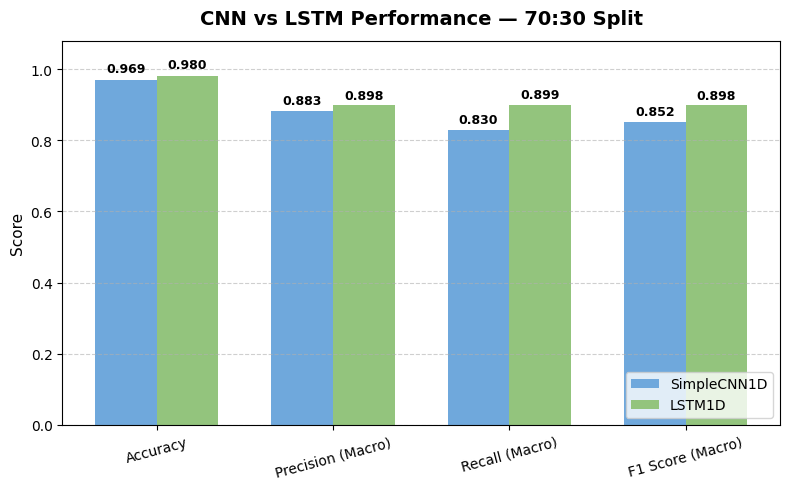

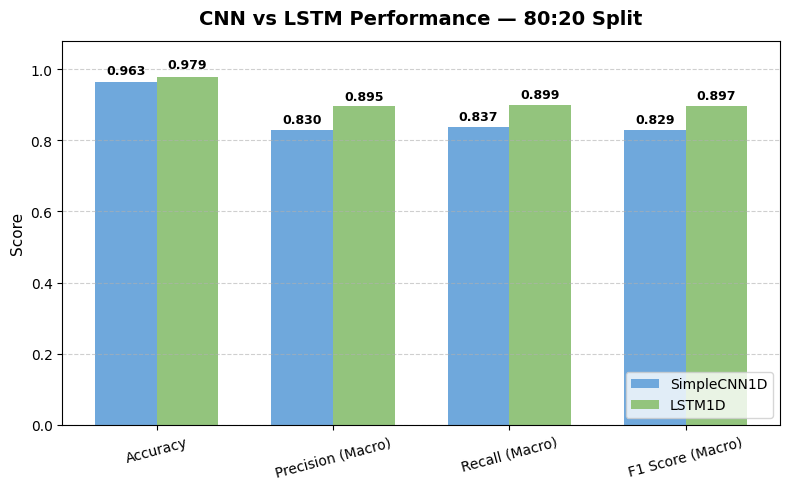

In [37]:
# ===============================================================
# 📊 Split-wise Bar Graphs for CNN vs LSTM (Balanced, 30 Epochs)
# ===============================================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === Load stored results ===
df = pd.read_csv("artifacts/experiment_results_all.csv")

# === Filter for balanced CNN & LSTM (30 epochs only) ===
df_bal = df[
    (df["balanced"] == True) &
    (df["epochs"] == 30) &
    (df["model"].isin(["SimpleCNN1D", "LSTM1D"])) &
    (df["split_train"].isin([0.6, 0.7, 0.8]))
].copy()

# ===============================================================
# 📊 Define metrics and pretty names
# ===============================================================
metrics = {
    "test_acc": "Accuracy",
    "test_prec_macro": "Precision (Macro)",
    "test_rec_macro": "Recall (Macro)",
    "test_f1_macro": "F1 Score (Macro)"
}

splits = {
    0.6: "60:40 Split",
    0.7: "70:30 Split",
    0.8: "80:20 Split"
}

# ===============================================================
# 🎨 Create bar plots for each split separately
# ===============================================================
plt.style.use("seaborn-v0_8-deep")  # clean professional theme

for split_val, split_name in splits.items():
    sub = df_bal[df_bal["split_train"] == split_val]

    if sub.empty:
        print(f"⚠️ No results found for {split_name}")
        continue

    # Prepare data for plotting
    cnn_row = sub[sub["model"] == "SimpleCNN1D"].iloc[0]
    lstm_row = sub[sub["model"] == "LSTM1D"].iloc[0]

    cnn_values = [cnn_row[m] for m in metrics.keys()]
    lstm_values = [lstm_row[m] for m in metrics.keys()]

    x = np.arange(len(metrics))
    width = 0.35

    # Plot bars
    fig, ax = plt.subplots(figsize=(8, 5))
    bars_cnn = ax.bar(x - width/2, cnn_values, width, label='SimpleCNN1D', color="#6fa8dc")
    bars_lstm = ax.bar(x + width/2, lstm_values, width, label='LSTM1D', color="#93c47d")

    # Annotate bars with raised labels (no overlap)
    for bar in bars_cnn:
        height = bar.get_height()
        offset = 0.01 if height < 0.9 else 0.015  # adaptive offset
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + offset,
            f"{height:.3f}",
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

    for bar in bars_lstm:
        height = bar.get_height()
        offset = 0.01 if height < 0.9 else 0.015
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + offset,
            f"{height:.3f}",
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

    # Styling
    ax.set_title(f"CNN vs LSTM Performance — {split_name}", fontsize=14, pad=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(list(metrics.values()), rotation=15)
    ax.set_ylabel("Score", fontsize=11)
    ax.set_ylim(0, 1.08)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.legend(loc='lower right', fontsize=10)
    plt.tight_layout()
    plt.show()


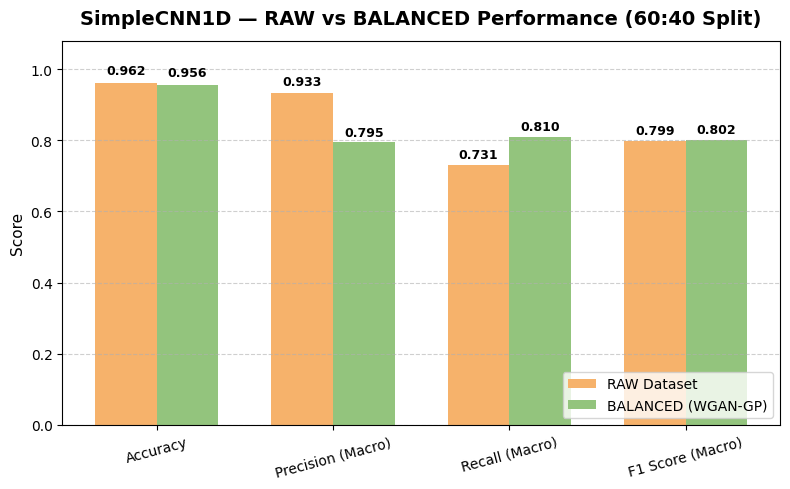

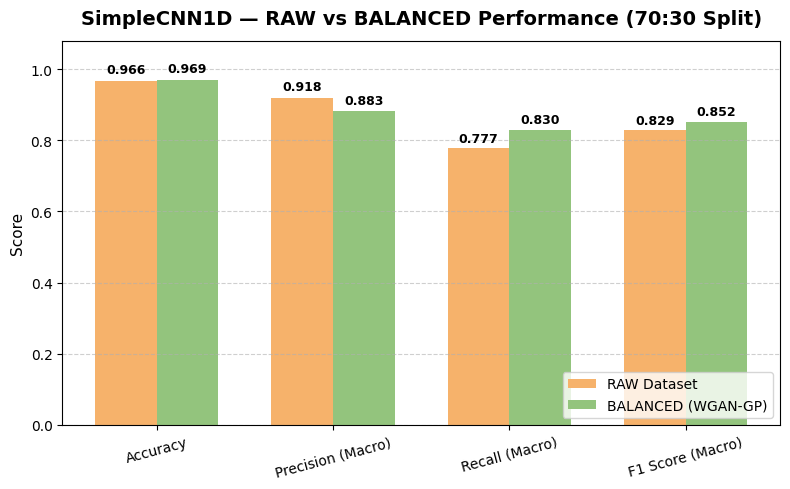

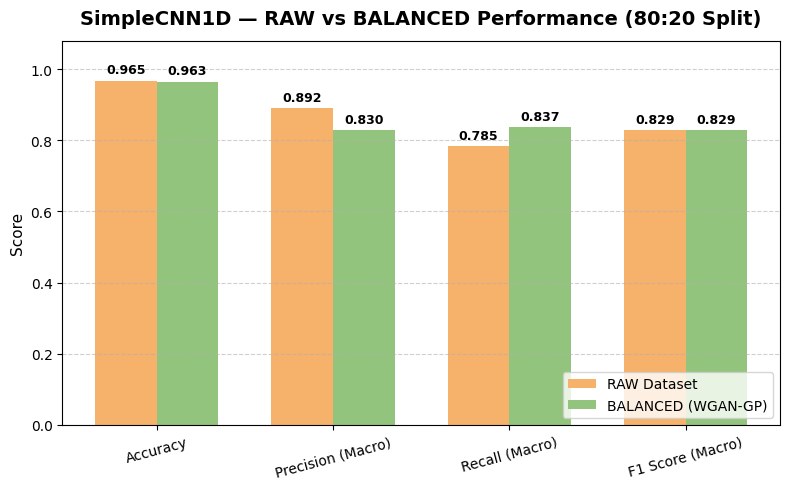


==================== 📈 SimpleCNN1D — RAW vs BALANCED Results (30 Epochs) ====================
      Split  Raw_Accuracy  Balanced_Accuracy  Raw_Precision  Balanced_Precision  Raw_Recall  Balanced_Recall  Raw_F1  Balanced_F1
60:40 Split         0.962              0.956          0.933               0.795       0.731            0.810   0.799        0.802
70:30 Split         0.966              0.969          0.918               0.883       0.777            0.830   0.829        0.852
80:20 Split         0.965              0.963          0.892               0.830       0.785            0.837   0.829        0.829

✅ Results saved to: artifacts/SimpleCNN1D_raw_vs_balanced_summary.csv


In [38]:
# ===============================================================
# 📊 Split-wise Bar Graphs & Results for RAW vs BALANCED (30 Epochs)
# ===============================================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === Load stored results ===
df = pd.read_csv("artifacts/experiment_results_all.csv")

# === Choose the model for comparison (SimpleCNN1D or LSTM1D) ===
MODEL_NAME = "SimpleCNN1D"   # change to "LSTM1D" if needed

# === Filter for given model (30 epochs only) ===
df_model = df[
    (df["model"] == MODEL_NAME) &
    (df["epochs"] == 30) &
    (df["split_train"].isin([0.6, 0.7, 0.8]))
].copy()

# ===============================================================
# 📊 Define metrics and split labels
# ===============================================================
metrics = {
    "test_acc": "Accuracy",
    "test_prec_macro": "Precision (Macro)",
    "test_rec_macro": "Recall (Macro)",
    "test_f1_macro": "F1 Score (Macro)"
}

splits = {
    0.6: "60:40 Split",
    0.7: "70:30 Split",
    0.8: "80:20 Split"
}

plt.style.use("seaborn-v0_8-deep")

# ===============================================================
# 🎨 Generate bar plots and collect results
# ===============================================================
results_table = []

for split_val, split_name in splits.items():
    sub = df_model[df_model["split_train"] == split_val]

    if sub.empty:
        print(f"⚠️ No results found for {split_name}")
        continue

    raw_row = sub[sub["balanced"] == False].iloc[0]
    bal_row = sub[sub["balanced"] == True].iloc[0]

    raw_values = [raw_row[m] for m in metrics.keys()]
    bal_values = [bal_row[m] for m in metrics.keys()]
    x = np.arange(len(metrics))
    width = 0.35

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8, 5))
    bars_raw = ax.bar(x - width/2, raw_values, width, label='RAW Dataset', color="#f6b26b")
    bars_bal = ax.bar(x + width/2, bal_values, width, label='BALANCED (WGAN-GP)', color="#93c47d")

    # --- Annotate bars ---
    for bar in bars_raw + bars_bal:
        height = bar.get_height()
        offset = 0.01 if height < 0.9 else 0.015
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + offset,
            f"{height:.3f}",
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

    # --- Styling ---
    ax.set_title(f"{MODEL_NAME} — RAW vs BALANCED Performance ({split_name})", fontsize=14, pad=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(list(metrics.values()), rotation=15)
    ax.set_ylabel("Score", fontsize=11)
    ax.set_ylim(0, 1.08)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.legend(loc='lower right', fontsize=10)
    plt.tight_layout()
    plt.show()

    # --- Save results to table ---
    results_table.append({
        "Split": split_name,
        "Raw_Accuracy": round(raw_row["test_acc"], 3),
        "Balanced_Accuracy": round(bal_row["test_acc"], 3),
        "Raw_Precision": round(raw_row["test_prec_macro"], 3),
        "Balanced_Precision": round(bal_row["test_prec_macro"], 3),
        "Raw_Recall": round(raw_row["test_rec_macro"], 3),
        "Balanced_Recall": round(bal_row["test_rec_macro"], 3),
        "Raw_F1": round(raw_row["test_f1_macro"], 3),
        "Balanced_F1": round(bal_row["test_f1_macro"], 3)
    })

# ===============================================================
# 📋 Display neatly formatted results
# ===============================================================
results_df = pd.DataFrame(results_table)
print(f"\n==================== 📈 {MODEL_NAME} — RAW vs BALANCED Results (30 Epochs) ====================")
print(results_df.to_string(index=False))

# Optional: Save summary
results_df.to_csv(f"artifacts/{MODEL_NAME}_raw_vs_balanced_summary.csv", index=False)
print(f"\n✅ Results saved to: artifacts/{MODEL_NAME}_raw_vs_balanced_summary.csv")


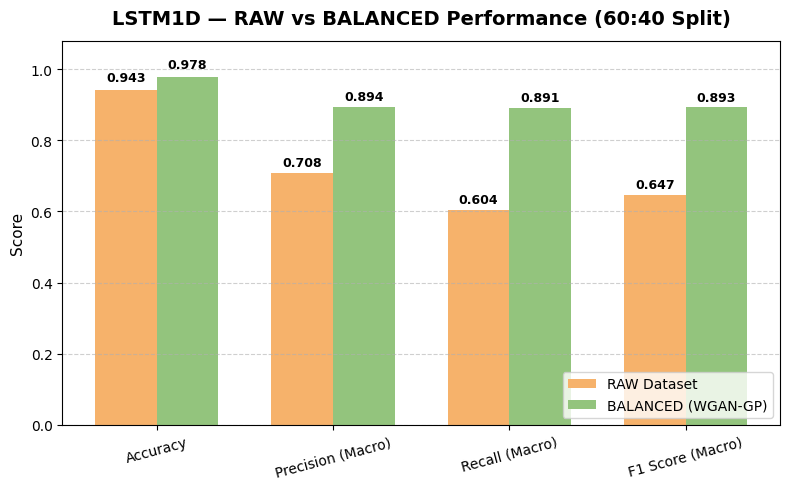

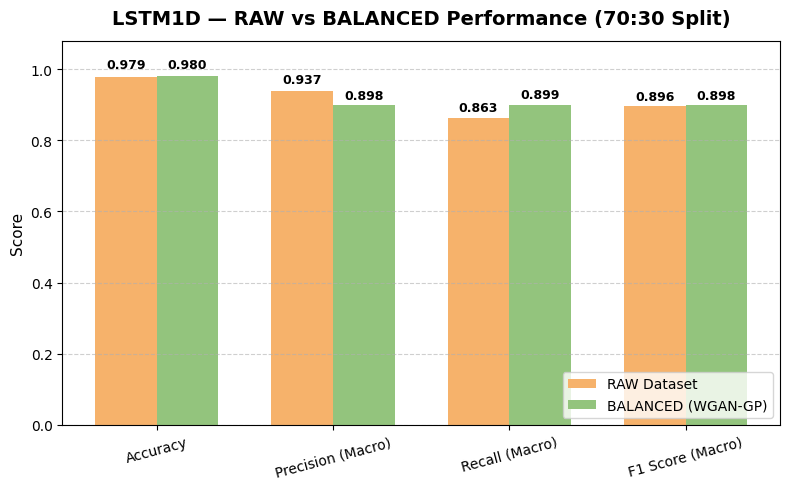

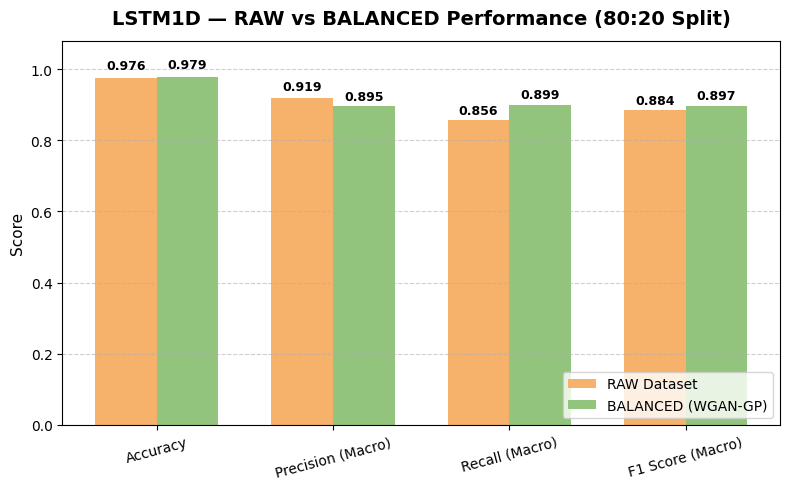


==================== 📈 LSTM1D — RAW vs BALANCED Results (30 Epochs) ====================
      Split  Raw_Accuracy  Balanced_Accuracy  Raw_Precision  Balanced_Precision  Raw_Recall  Balanced_Recall  Raw_F1  Balanced_F1
60:40 Split         0.943              0.978          0.708               0.894       0.604            0.891   0.647        0.893
70:30 Split         0.979              0.980          0.937               0.898       0.863            0.899   0.896        0.898
80:20 Split         0.976              0.979          0.919               0.895       0.856            0.899   0.884        0.897

✅ Results saved to: artifacts/LSTM1D_raw_vs_balanced_summary.csv


In [3]:
# ===============================================================
# 📊 Split-wise Bar Graphs & Results for RAW vs BALANCED (30 Epochs)
# ===============================================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === Load stored results ===
df = pd.read_csv("artifacts/experiment_results_all.csv")

# === Choose the model for comparison (SimpleCNN1D or LSTM1D) ===
MODEL_NAME = "LSTM1D"   # change to "LSTM1D" if needed

# === Filter for given model (30 epochs only) ===
df_model = df[
    (df["model"] == MODEL_NAME) &
    (df["epochs"] == 30) &
    (df["split_train"].isin([0.6, 0.7,0.8]))
].copy()

# ===============================================================
# 📊 Define metrics and split labels
# ===============================================================
metrics = {
    "test_acc": "Accuracy",
    "test_prec_macro": "Precision (Macro)",
    "test_rec_macro": "Recall (Macro)",
    "test_f1_macro": "F1 Score (Macro)"
}

splits = {
    0.6: "60:40 Split",
    0.7: "70:30 Split",
    0.8: "80:20 Split"
}

plt.style.use("seaborn-v0_8-deep")

# ===============================================================
# 🎨 Generate bar plots and collect results
# ===============================================================
results_table = []

for split_val, split_name in splits.items():
    sub = df_model[df_model["split_train"] == split_val]

    if sub.empty:
        print(f"⚠️ No results found for {split_name}")
        continue

    raw_row = sub[sub["balanced"] == False].iloc[0]
    bal_row = sub[sub["balanced"] == True].iloc[0]

    raw_values = [raw_row[m] for m in metrics.keys()]
    bal_values = [bal_row[m] for m in metrics.keys()]
    x = np.arange(len(metrics))
    width = 0.35

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8, 5))
    bars_raw = ax.bar(x - width/2, raw_values, width, label='RAW Dataset', color="#f6b26b")
    bars_bal = ax.bar(x + width/2, bal_values, width, label='BALANCED (WGAN-GP)', color="#93c47d")

    # --- Annotate bars ---
    for bar in bars_raw + bars_bal:
        height = bar.get_height()
        offset = 0.01 if height < 0.9 else 0.015
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + offset,
            f"{height:.3f}",
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold'
        )

    # --- Styling ---
    ax.set_title(f"{MODEL_NAME} — RAW vs BALANCED Performance ({split_name})", fontsize=14, pad=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(list(metrics.values()), rotation=15)
    ax.set_ylabel("Score", fontsize=11)
    ax.set_ylim(0, 1.08)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    ax.legend(loc='lower right', fontsize=10)
    plt.tight_layout()
    plt.show()

    # --- Save results to table ---
    results_table.append({
        "Split": split_name,
        "Raw_Accuracy": round(raw_row["test_acc"], 3),
        "Balanced_Accuracy": round(bal_row["test_acc"], 3),
        "Raw_Precision": round(raw_row["test_prec_macro"], 3),
        "Balanced_Precision": round(bal_row["test_prec_macro"], 3),
        "Raw_Recall": round(raw_row["test_rec_macro"], 3),
        "Balanced_Recall": round(bal_row["test_rec_macro"], 3),
        "Raw_F1": round(raw_row["test_f1_macro"], 3),
        "Balanced_F1": round(bal_row["test_f1_macro"], 3)
    })

# ===============================================================
# 📋 Display neatly formatted results
# ===============================================================
results_df = pd.DataFrame(results_table)
print(f"\n==================== 📈 {MODEL_NAME} — RAW vs BALANCED Results (30 Epochs) ====================")
print(results_df.to_string(index=False))

# Optional: Save summary
results_df.to_csv(f"artifacts/{MODEL_NAME}_raw_vs_balanced_summary.csv", index=False)
print(f"\n✅ Results saved to: artifacts/{MODEL_NAME}_raw_vs_balanced_summary.csv")
